# CIEM5220 - Wind and Wave Loads on Offshore Wind Turbines
## Finite Element Model of a Monopile Wind Turbine

**Course:** CIEAM5220 Applied Dynamics of Structures

**Unit 2:** Wind & Waves

---

### Structure Overview

The offshore wind turbine (OWT) is modelled as a vertical cantilever beam fixed at the mudline. The structure consists of two zones:

-**Submerged zone** ($H_w=36$ m): from mudline to mean water lever, subject to wave loading

-**Above-water zone** ($H_a=108$ m): from water level to hub, subject to wind loading

The nacelle and rotor are represented as a concentrated mass $M_{nacelle}$ at the tip.

### Modelling Approach

An Euler-Bernoulli beam finite element model is used. Each node has two degrees of freedom, lateral displacement $w$ and rotation $\theta$. Hermitian cubic shape functions ensure $C^1$ continuity (displacement and slope are continuous across elements).

### Design Objective

The first natural frequency $f_1$ must fall in the **soft-stiff window** between the 1P (rotor) and 3P (blade passing) frequencies. A target of $f_1 \geq 1.1 \times f_{1P}$ is used to provide a safety margin above 1P. The outer diameter $D_o$ is tuned by sweeping until this target is met. 




<img src="Turbine.png.pdf" width="450" style="display:block; margin:auto"/>

In [205]:
# ===== IMPORTS =========
import numpy as np
import sympy as sp
import matplotlib.pyplot as plt

from scipy.linalg import eigh
from scipy.optimize import brentq

x=sp.Symbol('x')



In [ ]:
# ====== GEOMETRY & MATERIAL ========
D_o = 5                          # [m]  
t=0.08                          # [m]  
Di = D0-2*t                     # [m]
A = np.pi/4*(D0**2-Di**2)       # [m^2]
I = np.pi/64*(D0**4-Di**4)      # [m^-4]
rho = 7850                      # steel [kg/m^3] ##
E = 210e9                       # [Pa]

EI=E*I
rhoA=rho*A

Hw=36.0                         # [m]
Ha=108.0                        # [m]
L=Hw+Ha                         # [m]  

M_nacelle=6e5       # [kg] 

In [207]:
# ====== ROTOR PARAMETERS ========
Omega_max=7.6                   # [rpm]
f_1P=Omega_max/60               # [Hz]
f_3P=3*f_1P                     # [Hz]
f_target=1.1*f_1P               # [Hz]

print(f"1P frequency: {f_1P:.4f} Hz")
print(f"3P frequency: {f_3P:.4f} Hz")
print(f"Target f1 (>=1.1*1P): {f_target:.4f} Hz")

1P frequency: 0.1267 Hz
3P frequency: 0.3800 Hz
Target f1 (>=1.1*1P): 0.1393 Hz


#### Shape functions #
For each element the shape functions describe the transverse (lateral) displacement and rotation at both end-nodes. The four shape functions $[N_1,\ N_2,\ N_3,\ N_4]$ are cubic Hermite polynomials, chosen so that the deflected shape of the beam is smooth and continuous, meaning both the displacement and its slope (rotation) are continuous across element boundaries.

The displacement field within an element is approximated as:
$$w(x)=\sum_{i=1}^{4} N_i(x)\, u_i$$

where the shape functions are defined in terms of the normalised local coordinate $\xi=x/l_e\in[0,\,1]$:

$$N_1=1-3\xi^2+2\xi$$
$$N_2=l_e\,(\xi-2\xi^2+\xi^3)$$
$$N_3=3\xi^2-2\xi^3$$
$$N_4=l_e\,(-\xi^2+\xi^3)$$

In [208]:
# ==== SHAPE FUNCTIONS ====

def shape_functions(le):

    """
    Returns Euler - Bernoulli shape functions 
    for element of length le. Symbolic in x (sympy)
    Call as B= shape_functions(le)
    """

    x= sp.Symbol('x')

    N1=1-3*(x/le)**2 + 2*(x/le)**3
    N2=x*(1 - x/le)**2
    N3=3*(x/le)**2 - 2*(x/le)**3
    N4=(x**2/le)*(x/le - 1)
    
    return [N1, N2, N3, N4]


#### Finite Element Formulation

The wind turbine tower is modelled as an Euler-Bernoulli beam and discretised into **12 elements of equal length** $l_e$, with 3 submerged elements and 9 above the waterline. Each node carries two degrees of freedom, lateral displacement $w$ and rotation $\theta$ , giving 4 DOFs per element.

---

**Element stiffness matrix**

The stiffness matrix is assembled from the second derivatives of the shape functions, which relate to the beam curvature and bending strain:

$$\mathbf{K}_e=EI\int_0^{l_e} \mathbf{N}''(x)^\top \mathbf{N}''(x)\, dx$$

This evaluates to:

$$\mathbf{K}_e=\frac{EI}{l_e^3}
\begin{bmatrix}
12 & 6l_e & -12 & 6l_e \\
6l_e & 4l_e^2 & -6l_e & 2l_e^2 \\
-12 & -6l_e & 12 & -6l_e \\
6l_e & 2l_e^2 & -6l_e & 4l_e^2
\end{bmatrix}$$

---

**ELement mass matrix**

The consistent mass matrix distributes the element's inertia according tp the shape functions, rather than lumping it at the nodes:

$$\mathbf{M}_e=\rho A \int_0^{l_e} \mathbf{N}(x)^\top \mathbf{N}(x)\, dx $$

Which evaluates to:

$$\mathbf{M}_e=\frac{\rho A l_e}{420}
\begin{bmatrix}
156 & 22l_e & 54 & -13l_e \\
22l_e & 4l_e^2 & 13l_e & -3l_e^2 \\
54 & 13l_e & 156 & -22l_e \\
-13l_e & -3l_e^2 & -22l_e & 4l_e^2
\end{bmatrix}$$


In [209]:
#==== STIFFNESS AND MASS MATRICES ======
def element_stiffness(le, EI):
    """
    Returns Euler - Bernoulli stiffness matrix
    length le, EI=Emodulus*inertia 
    """
    return EI/le**3*np.array([
    [12,      6*le,   -12,   6*le ],
    [6*le, 4*le**2, -6*le, 2*le**2], 
    [-12,    -6*le,    12,  -6*le ],
    [6*le, 2*le**2, -6*le, 4*le**2],
    ])

def element_mass(le, rhoA):
    """
    Returns Euler - Bernoulli mass matrix
    length le, rhoA=mass per meter*Area
    """
    return rhoA*(le/420)*np.array([       
    [156,    22*le,      54,   -13*le        ],
    [22*le,  4*le**2,   13*le,   3*le**2     ],
    [54,     13*le,      156,   -22*le       ],
    [-13*le, -3*le**2, -22*le, 4*le**2       ],
    ])

#### Natural Frequency and Diameter Sweep

The first natural frequency $f_1$ of the tower is estimated by solving the generalised eigenvalue problem assembled from the global stiffness and mass matrices. For a given trial diameter $D_o$, the wall thickness is set by the diameter-to-thickness ratio $D_t=D_o/t$, from which the cross-sectional area $A$ and second moment of area $I$ follows

$$A=\frac{\pi}{4}\left(D_o^2-D_i^2\right), \qquad I = \frac{\pi}{64}\left(D_o^4-D_i^4\right), \qquad D_i=D_o-2t$$

The element stiffness and mass matrices are recomputed for each trial diameter, assembled into the global system, and the lowest eigenfrequency is extracted:

$$f_1=\frac{\omega_1}{2\pi}, \qquad\omega_1=\sqrt{\lambda_1}$$

where $\lambda_1$ is the smallest eigenvalue of the free DOF system $\mathbf{K}_{\text{free}}\, \mathbf{v}=\lambda\,\mathbf{M}_{\text{free}}\,\mathbf{v}$.

---

To find the optimal diameter, $D_o$ is swept from 3.0 m upward in steps of 0.01 m. The target is the **soft-stiff window**, the design band between the 1P frequency (rotor rotation) and the 3P frequency (blade passing), within which resonance with bot excitation sources is avoided:

$$f_{1P} < f_1 < f_{3P}$$

A minimum marigin of 10% above 1P is adopted as the design target. This separation also guards against long-term downward drift of $f_1$ caused by scour and cyclic soil softening around the monopile foundation (Sumer and Fredsøe, 2002).

In [ ]:
# ==== COMPUTE F1 ====

def compute_f1(elements, ndof, Dt_ratio, D_o_try, E, rho, Hw, Ha, L, elem_w, elem_a, le, M_nacelle):
    t_try=D_o_try/Dt_ratio
    Di_try=D_o_try-2*t_try
    A_try=np.pi/4*(D_o_try**2-Di_try**2)
    I_try=np.pi/64*(D_o_try**4-Di_try**4)
    EI_try=E*I_try
    rhoA_try=rho*A_try

    Ke_try=element_stiffness(le, EI_try)
    Me_try=element_mass(le, rhoA_try)

    K_try=np.zeros((ndof, ndof))
    M_try=np.zeros((ndof, ndof))

    for e in range(elements):
        dofs=[2*e, 2*e+1, 2*e+2, 2*e+3]
        for i in range(4):
            for j in range(4):
                K_try[dofs[i], dofs[j]] += Ke_try[i,j]
                M_try[dofs[i], dofs[j]]+= Me_try[i,j]

    M_try[ndof-2, ndof-2] += M_nacelle
    free=np.arange(2, ndof)
    K_free_try=K_try[np.ix_(free, free)]
    M_free_try=M_try[np.ix_(free, free)]

    eigenvalues, _ = eigh(K_free_try, M_free_try)
    omega_try=np.sqrt(eigenvalues)
    return omega_try[0]/(2*np.pi)


In [223]:
# ==== DIAMETER SWEEP ====

Dt_ratio=90
D_o_range=np.arange(3.0, 10.0, 0.01) # sweep diameters [m]

elements=12
le=L/elements
elem_w=int(Hw/le)        # elements in submerged zone
elem_a=elements-elem_w   # elements in air zone 

nodes          = elements+1
DOF            = 2             # (w, theta)
ndof           = nodes*DOF

D_o_list=[]
f1_list=[]

for D_o_try in D_o_range:
    f1_try=compute_f1(elements, ndof, Dt_ratio, D_o_try, E, rho, 
                      Hw, Ha, L, elem_w, elem_a, le, M_nacelle)
    D_o_list.append(D_o_try)
    f1_list.append(f1_try)
    if f1_try>= f_target:
        D_o=D_o_try
        t=D_o/Dt_ratio
        break

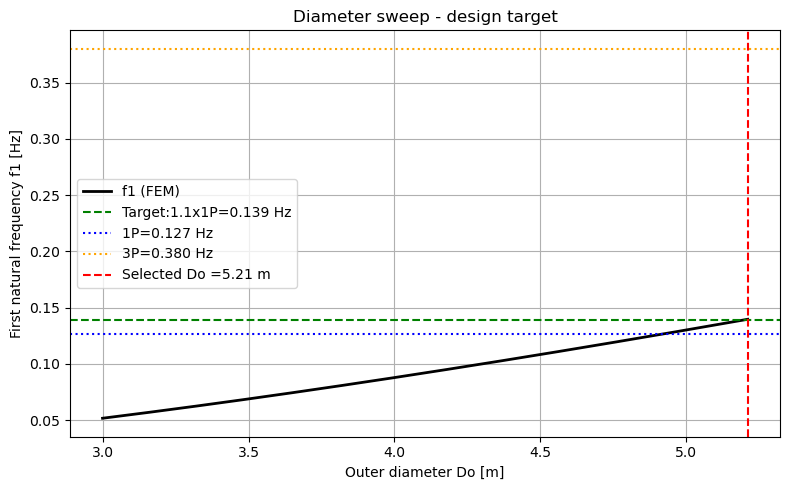


 Diameter Tuning
D/t ratio:        90
Do=               5.210 m
t=                0.0579m
f1 achieved=      0.1397 Hz
Margin above 1P = 10.3%


In [224]:
# ==== PLOT, DIAMETER SWEEP ====

fig_sweep, ax_sweep=plt.subplots(figsize=(8,5))
ax_sweep.plot(D_o_list, f1_list, 'k', linewidth=2, label='f1 (FEM)')
ax_sweep.axhline(f_target, color='green', linestyle='--', label=f'Target:1.1x1P={f_target:.3f} Hz')
ax_sweep.axhline(f_1P, color='blue', linestyle=':', label=f'1P={f_1P:.3f} Hz')
ax_sweep.axhline(f_3P, color='orange', linestyle=':', label=f'3P={f_3P:.3f} Hz')
ax_sweep.axvline(D_o, color='red', linestyle='--', label=f'Selected Do ={D_o:.2f} m')
ax_sweep.set_xlabel('Outer diameter Do [m]')
ax_sweep.set_ylabel('First natural frequency f1 [Hz]')
ax_sweep.set_title('Diameter sweep - design target')
ax_sweep.legend()
ax_sweep.grid(True)
plt.tight_layout()
plt.show()


print(f"\n Diameter Tuning")
print(f"D/t ratio:        {Dt_ratio}")
print(f"Do=               {D_o:.3f} m")
print(f"t=                {t:.4f}m")
print(f"f1 achieved=      {f1_try:.4f} Hz")
print(f"Margin above 1P = {(f1_try/f_1P-1)*100:.1f}%")


#### Results, Diameter Sweep

The sweep identifies the smallest diameter for which $f_1$ falls within the soft-stiff window. The resulting design is:

| Parameter | Value |
|---|--|
| $D/t$ ratio | 90 |
| Outer diameter $D_o$| 5.210 m |
| Wall thickness $t$ | 0.0579 m |
| First natural frequency $f_1$ | 0.1397 Hz |
| Margin above 1P | 10.3 % |

A $D/t$ ratio of 90 is consistent with typical offshore monopile design practice, balancing structural efficiency against local buckling risk. The achieved frequency of **0.1397 Hz** sits within the soft-stiff window with a 10.3 % margin above the 1P threshold, providing adequate separation from rotor excitation while remaining below the 3P blade passing frequency.

A minimum margin of 10% above 1P is adopted as the design target, consistent with standard industry practive (DNV-OS-J101). This seperation is not merely a rule of thumb, it also guards against long-term downward drift of $f_1$ caused by scour and cyclic soil softening around the monopile foundation, both of which reduce effective foundation stiffness over the turbine lifetime. 

Update of cross-section properties after sweep with new diameter before assembling.

In [ ]:
# ==== CROSS-SECTION UPDATE ====

Di=D0-2*t
A=np.pi/4*(D0**2-Di**2)
I=np.pi/64*(D0**4-Di**4)
EI=E*I
rhoA=rho*A

print(f"A={A:.6f}m^2")
print(f"I={I:.6f} m^4")

A=0.936980m^2
I=3.109321 m^4


Assembling the global K & M matrices by looping over elements and adding each element contribution using the direct stiffness method. 

In [82]:
# ====== FE MODEL SETUP ========

B = shape_functions(le)
Ke = element_stiffness(le, EI)
Me = element_mass(le, rhoA)

# ======= ASSEMBLY ========
K =np.zeros((ndof,ndof))
M =np.zeros((ndof,ndof))

for e in range(elements):
    dofs=[2*e, 2*e+1, 2*e+2, 2*e+3]
    for i in range(4):
        for j in range(4):
            K[dofs[i], dofs[j]] += Ke[i,j]
            M[dofs[i], dofs[j]] += Me[i,j]

# ===== BOUNDARY CONDITIONS =======
# clamped base: remove DOFs 0 and 1
free=np.arange(2, ndof)
K_free=K[np.ix_(free,free)]
M_free=M[np.ix_(free,free)]

### Assembly Verification, Static Sanity Check

Before introducing the nacelle mass or dynamic loading, the globalstiffness assembly is verified against analytical solutions for a cantilever beam under a uniformly distributed load $q=1\ \text{kN/m}$.

For a cantilever of length $L$ with uniform $EI$, the tip deflection and mudline (base) bending moment have closed-form solutions:

$u_{\text{tip}}=\frac{qL^4}{8EI}, \qquad M_{\text{mudline}}= \frac{qL^2}{2}$ 

The equivalent nodal forces are computed by projecting the distributed load onto the shape functions:

$f_e^{(i)}=\int_0^{l_e} N_i(x)\, q\,dx$

and assembled into the global force vector. Solving the reduced system $\mathbf{K}_{\text{free}}\,\mathbf{u}=\mathbf{f}_{\text{free}}$ and recovering the tip displacement and mudline moment from the FE solution allows a direct comparison. Close agreement between the two confirms that the element formulation, assembly, and boundary conditions are correctly implemented. 

In [83]:
# ====== SANITY CHECK ========
# Uniform load over full length, no nacelle mass
# Analytical: u_tip = qL^4/8EI, M_mudline= qL^2/2
q_check=1e3             # [N/m] uniform load
f_check=np.zeros(ndof)

for e in range(elements):
    fe=np.array([
        float(sp.integrate(Ni*q_check, (x, 0, le))) for Ni in B
    ])
    dofs=[2*e, 2*e+1, 2*e+2, 2*e+3]
    for i in range(4):
        f_check[dofs[i]]+=fe[i]
    

f_check_free         = f_check[free]
u_check              = np.linalg.solve(K_free, f_check_free)
u_tip_FE             = u_check[-2]
u_check_full         = np.zeros(ndof)
u_check_full[free]   = u_check
u_e0                 = u_check_full[0:4]
M_mudline_FE         = EI*sum(
    float(sp.diff(Ni, x, 2).subs(x, 0))*u_e0[i]
    for i, Ni in enumerate(B)
)
u_tip_analytical     = q_check*L**4/(8*EI)
M_mudline_analytical = q_check*L**2/2

print(f"\n--- Sanity Check (uniform load q={q_check} N/m, no nacelle)---")
print(f"Tip deflection FE: {u_tip_FE:.6f} m")
print(f"Tip deflection Analytical: {u_tip_analytical:.6f} m")
print(f"Mudline moment FE: {M_mudline_FE/1e6:.3f} MNm")
print(f"Mudline moment Analytical: {M_mudline_analytical/1e6:.3f} MNm")



--- Sanity Check (uniform load q=1000.0 N/m, no nacelle)---
Tip deflection FE: 0.082314 m
Tip deflection Analytical: 0.082314 m
Mudline moment FE: 10.356 MNm
Mudline moment Analytical: 10.368 MNm


### Sanity Check Results


| Quantity | FE Solution | Analytical | Difference |
|---|---|---|---|
| Tip deflection | 0.082314 m | 0.082314 m | < 0.001 % |
| Mudline moment | 10.356 MNm | 10.368 MNm | 0.12 % |

The tip deflection matches the analytica solution exactly, confirming that the stiffness assembly and boundary conditions are correctly implemented. The mudline moment shows a small discrepancy of 0.12 % , which is expected. The bending moment is recovered by differentiating the displacement field at the element boundary, an operation thhat is inherently less accurate than the displacement solution itself. Both results are well within acceptable tolerance for a 12-element discretisation.

In [84]:
#========= + NACELLE MASS ===========
M[ndof-2, ndof-2]+=M_nacelle
M_free=M[np.ix_(free, free)]

# ==== EIGENVALUE ANALYSIS =======
eigenvalues, eigenvectors=eigh(K_free, M_free)
omega=np.sqrt(eigenvalues)
freq=omega/(2*np.pi)

print(f"\n---Natural frequencies ---")
print(f"Mode 1: {freq[0]:.4f} Hz (target >={f_target:.4f} Hz)")
print(f"Mode 2: {freq[1]:.4f} Hz")
print(f"Soft-stiff window: {f_1P:.4f}-{f_3P:.4f} Hz")



---Natural frequencies ---
Mode 1: 0.1397 Hz (target >=0.1393 Hz)
Mode 2: 1.2122 Hz
Soft-stiff window: 0.1267-0.3800 Hz


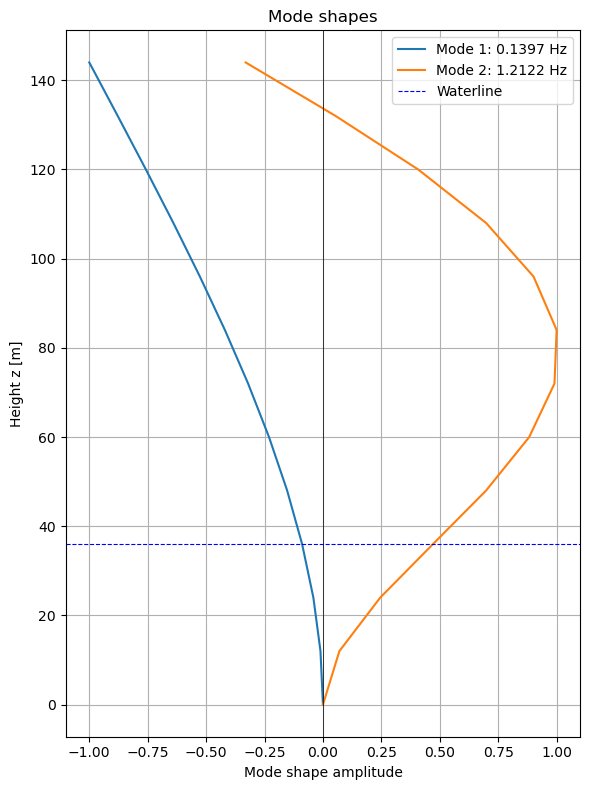

In [ ]:
# ==== PLOT, MODE SHAPES (1,2) ====


fig3, ax=plt.subplots(figsize=(6, 8))

# height coordinates of each node
z_nodes=np.array([i*le for i in range(nodes)])

for mode in range(2):
    # extract lateral displacement DOFs (every other DOF starting from 0)
    phi=eigenvectors[:,mode]  # full free DOF eigenvector

    # lateral displacements are even indices of free DOFs
    phi_lateral=phi[0::2]  # every other entry starting from 0
    phi_plot=np.concatenate([[0], phi_lateral])
    
    #normalise to max=1
    phi_plot=np.concatenate([[0], phi_lateral])
    phi_plot=phi_plot/np.max(np.abs(phi_plot)) 

    ax.plot(phi_plot, z_nodes, label=f'Mode {mode+1}: {freq[mode]:.4f} Hz')

ax.axhline(Hw, color= 'blue', linestyle='--', linewidth=0.8, label='Waterline')
ax.axvline(0,color='k', linewidth=0.5)
ax.set_xlabel('Mode shape amplitude')
ax.set_ylabel('Height z [m]')
ax.set_title('Mode shapes')
ax.legend()
ax.grid(True)
plt.tight_layout()
plt.show()

#### Scour Sensitivity, Natural Frequency vs Scour Depth

Scour is the erosion of seabed sediment around the monopile base driven by wave and current action. For an unprotected monopile in fine North Sea sand, the expected scour depth is approximately $1.0$-$1.5\times D_o$ (Sumer and Fredsøe, 2002), giving a worst-case estimate of $1.5 \times 5.21 \approx 7.8$ m for this design. 

Physically, scour increases the unsupported lenght of the pile, which reduces lateral foundation stiffness while simultaneously increasing the modal mass, both effects lower $f_1$. Following $L$ through the model: a longer $L$ increases $l_e=L/n$, which softens $\mathbf{K}_e\propto l_e^{-3}$ and increases $\mathbf{M}_e\propto l_e$, reducing the eigenfrequency as approximately $f_1\propto L^{-2}$

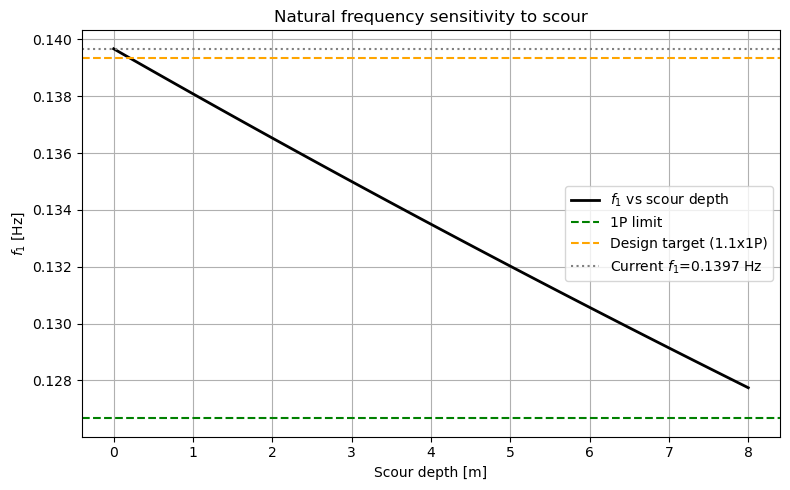

In [221]:
# ==== TEST, SCOUR SENSITIVITY ====
# Natural Frequency vs Scour Depth
scour_depths=np.linspace(0,8,50) # [m]
f1_scour=[]

for delta_L in scour_depths:
    L_scour=L+delta_L
    le_scour=L_scour/ elements
    f1_new=compute_f1(elements, ndof, Dt_ratio, D0, E, rho, Hw + delta_L, Ha, L_scour, elem_w, elem_a, le_scour, M_nacelle)
    f1_scour.append(f1_new)

f1_scour=np.array(f1_scour)

plt.figure(figsize=(8,5))
plt.plot(scour_depths, f1_scour, 'k', linewidth=2, label='$f_1$ vs scour depth')
plt.axhline(f_1P, color='green', linestyle='--', label='1P limit')
plt.axhline(f_target, color='orange', linestyle='--', label='Design target (1.1x1P)')
plt.axhline(freq[0], color='gray', linestyle=':', label=f'Current $f_1$={freq[0]:.4f} Hz')
plt.xlabel('Scour depth [m]')
plt.ylabel('$f_1$ [Hz]')
plt.title('Natural frequency sensitivity to scour')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


The plot confirms that $f_1$ remains above the 1P threshold up to a scour depth of approximately 9 m, providing margin beyond the worst-case estimate of 7.8 m. The 10% design margin above 1P therefore proves adequate for this site assumption. 

In practice, scour protection in the form of rock armour dumped around the pile base is standard for Noth Sea monopiles, which largely prevents scour from developing. The sensitivity study nonetheless demonstrates that the soft-stiff design remains rubust even under significant unprotected scour conditions (Sørensen and Ibsen, 2013).

#### Natural Frequencies and Mode Shapes

With the nacelle mass $M_{\text{nacelle}}$ added to the top node, the first two natural frequencies extracted from the eigenvalue problem are:

| Mode | Frequency |
|---|---|
| Mode 1 | 0.1397 Hz |
| Mode 2 | 1.2122 Hz |

The soft-stiff design window spans $0.1267\ \text{Hz} < f_1 < 0.3800\ \text{Hz}$, corresponding to the 1P and 3P rotor frequencies respectively. Mode 1 sits at **0.1397 Hz**, clearing the 1P threshold by 10.3 % and well below the 3P upper bound, confirming the design target is met.

Mode 2 at 1.2122 Hz lies well above the 3P frequency and is not a design driver for this loading regime. 

The mode shapes show the normlalised lateral displacement profiles along the tower height, illustrating the characteristic first-mode cantilever shape and the inflection point present in the second mode. 

#### Rayleigh Damping

To account for structural energy dissipation, damping is introduces via the Rayleigh model, where the damping matrix is a linear compination of the mass and stiffness matrices:

$\mathbf{C}=\alpha\mathbf{M}+\beta\mathbf{K}$

The modal damping ratio for mode $i$ is then:

$\zeta_i=\frac{\alpha}{2\omega_i}+\frac{\beta\omega_i}{2}$

Prescribing $\zeta_1=\zeta_2=0.02$ (2% critical damping) at both natural frequencies given the 2x2 system:

$\frac{\alpha}{2\omega_1} + \frac{\beta\omega_1}{2}=0.02$

$\frac{\alpha}{2\omega_2}+\frac{\beta\omega_2}{2}=0.02$



In [147]:
# ====== RAYLEIGH DAMPING ========
#Borth modes have 2% critical damping as per assignment

zeta1=0.02           # damping ratio mode 1
zeta2=0.02           # damping ratio mode 2
w1 = omega[0]        # first natural frequency [rad/s]
w2 = omega[1]        # second natural frequency [rad/s]

alpha   = 2*w1*w2*(zeta1*w2-zeta2*w1)/(w2**2-w1**2)
beta    = 2*(zeta2*w2-zeta1*w1)/(w2**2-w1**2)
C_free  = alpha * M_free + beta * K_free

print(f"\n--- Rayleigh Damping ---")
print(f"alpha={alpha:.6f}")
print(f"beta={beta:.6f}")



--- Rayleigh Damping ---
alpha=0.031477
beta=0.004709


Solving yields $\alpha=0.0315$ and $\beta=0.0047$. At frequencies below $\omega_1$ the mass-proportional term dominated, while above $\omega_2$ the stiffness-proportianl term dominates. The damping ratio rises on both sides of the pinned target modes. 

Althogh the turbine is treated as non-operating in this analysis and rotor excitation is neglected, the damping coefficients remain relevent as they govern dynamic amplification when the structure is excited near its natural frequencies. 

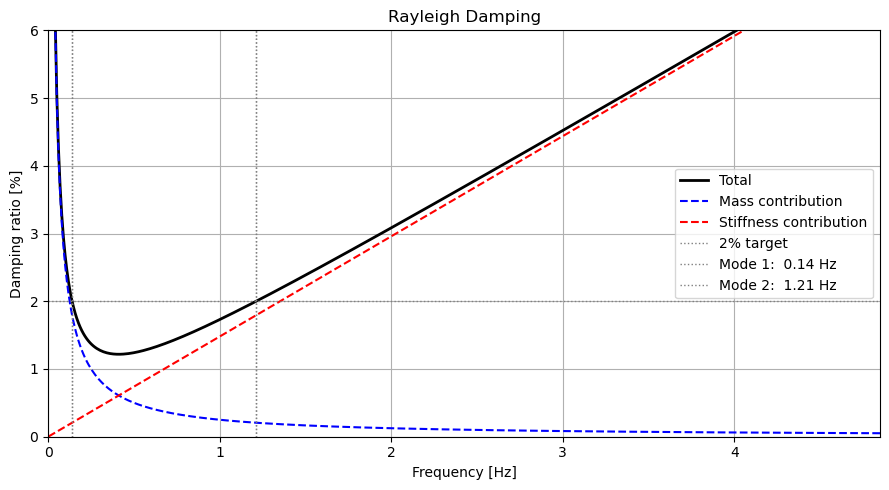

In [ ]:
# ==== RAYLEIGH DAMPING PLOT ======

omega_range=np.linspace(0.01, 4*w2,500) #frequency range [rad/s]
zeta_total=alpha/(2*omega_range)+beta*omega_range/2
zeta_mass = alpha/(2*omega_range)  # mass term - dominates at low frequencies
zeta_stiff=beta*omega_range/2    # stiffness term - dominates at high frequencies

fig2, ax = plt.subplots(figsize=(9,5))

ax.plot(omega_range/(2*np.pi), zeta_total*100, 'k', linewidth=2, label='Total')
ax.plot(omega_range/(2*np.pi), zeta_mass*100, 'b--', linewidth=1.5,label= 'Mass contribution')
ax.plot(omega_range/(2*np.pi), zeta_stiff*100, 'r--', linewidth=1.5, label='Stiffness contribution')

ax.axvline(w1/(2*np.pi), color='gray', linestyle=':', linewidth=1)
ax.axvline(w2/(2*np.pi), color='gray', linestyle=':', linewidth=1)

ax.axhline(2, color='gray', linestyle=':', linewidth=1, label='2% target' )
ax.axvline(w1/(2*np.pi), color='gray', linestyle=':', linewidth=1, label=f'Mode 1:  {w1/(2*np.pi):.2f} Hz')
ax.axvline(w2/(2*np.pi), color='gray', linestyle=':', linewidth=1, label=f'Mode 2:  {w2/(2*np.pi):.2f} Hz')

ax.set_xlim(0,4*w2/(2*np.pi))
ax.set_xlabel('Frequency [Hz]')
ax.set_ylabel('Damping ratio [%]')
ax.set_title('Rayleigh Damping')
ax.legend()
ax.grid(True)
ax.set_ylim(0, 6)
plt.tight_layout()
plt.show()

#### Load Cases

Two wors-case scenarios are investigated. LC1 targets peak resonance by setting the wave peak period equal to the first natural period of the structure, $T_p=T_1=1/f_1$. The corresponding wind speed is then back-calculated by inverting the fetch-wind relation using a root-finding algorithm. LC2 represents an extreme storm with a prescribed reference wind speed of $U_{10}=19$ m/s, from which both $T_p$ and $H_s$ are derived directly. 

The fetch-wind relations are empirical formulas from the JONSWAP experiment, fitted to North Sea measurements by Hasselmann et al. (1973), linking wind speed $U_{10}$ and fetch distance $F$ to wave characteristics:

$T_p=\frac{0.286}{g} \left(\frac{gF}{U_{10}^2}\right)^{1/3} U_{10}$

$H_s=\frac{0.0016}{g} \sqrt{\frac{gF}{U_{10}^2}}\, U_{10}^2$



In [149]:
# ====== LOAD CASES =======
f1=freq[0]
f2=freq[1]
T1=1/f1
g=9.81
F_fetch=180e3  # fetch [m]
z0=0.001       # roughness length, open sea [m]

# LC2 - reference wind speed given, derive wave period
U10_LC2 = 19.0
Tp_LC2= 0.286*(g*F_fetch/U10_LC2**2)**0.33*U10_LC2/g
Hs_LC2=0.0016*np.sqrt(g*F_fetch/U10_LC2**2)*U10_LC2**2/g

# LC1 - Wave peak period equals first natural period, derive wind speed
Tp_LC1=T1
U10_LC1=brentq(
    lambda U: 0.286*(g*F_fetch/U**2)**0.33*U/g-Tp_LC1, 
    1.0, 50.0
)
Hs_LC1=0.0016*np.sqrt(g*F_fetch/U10_LC1**2)*U10_LC1**2/g

print(f"\nLoad Cases")
print(f"LC1: U10= {U10_LC1:.2f} m/s, Tp= {Tp_LC1:.2f} s, Hs= {Hs_LC1:.2f}")
print(f"LC2: U10= {U10_LC2:.2f} m/s, Tp= {Tp_LC2:.2f} s, Hs= {Hs_LC2:.2f}")



Load Cases
LC1: U10= 9.26 m/s, Tp= 7.16 s, Hs= 2.01
LC2: U10= 19.00 m/s, Tp= 9.14 s, Hs= 4.12


With fetch $F=180$ km, the resulting load case parameters are:

| Parameter | LC1 | LC2 |
|---|---|---|
| $U_{10}$ | 9.26 m/s | 19.00 m/s |
| $T_p$ | 7.16 s | 9.14 s |
| $H_s$ | 2.01 m | 4.12 m |
| $\omega_p$ | 0.878 rad/s | 0.687 rad/s |


#### Mean Wind Profile

The mean wind speed at height $z$ above the waterline is described by a logarithmic profile:

$U(z)=U_{10} \frac{\ln(z/z_0)}{\ln(10/z_0)}$

where $z_0=0.001$ m is the surface roughness length for open sea. The profile is only applied above the waterline; submerged nodes carry no wind loading. 

In [194]:
# ===== MEAN WIND PROFILE =====
z_nodes=np.array([i*le for i in range(nodes)])
z_above=z_nodes-Hw
z0=0.001 # roughness length, open sea [m]

def mean_wind(U10, z, z0):
    z_pos=np.maximum(z, z0)
    return U10*np.log(z_pos/z0)/np.log(10.0/z0)

# only valid above waterline

U_mean_LC1=np.where(z_above > 0, mean_wind(U10_LC1, z_above, z0), 0.0)
U_mean_LC2=np.where(z_above > 0, mean_wind(U10_LC2, z_above, z0), 0.0)

print(f"\n Mean Wind Profile")
print(f"LC1 tip wind speed: {U_mean_LC1[-1]:.2f} m/s")
print(f"LC2 tip wind speed: {U_mean_LC2[-1]:.2f} m/s")




 Mean Wind Profile
LC1 tip wind speed: 11.66 m/s
LC2 tip wind speed: 23.91 m/s


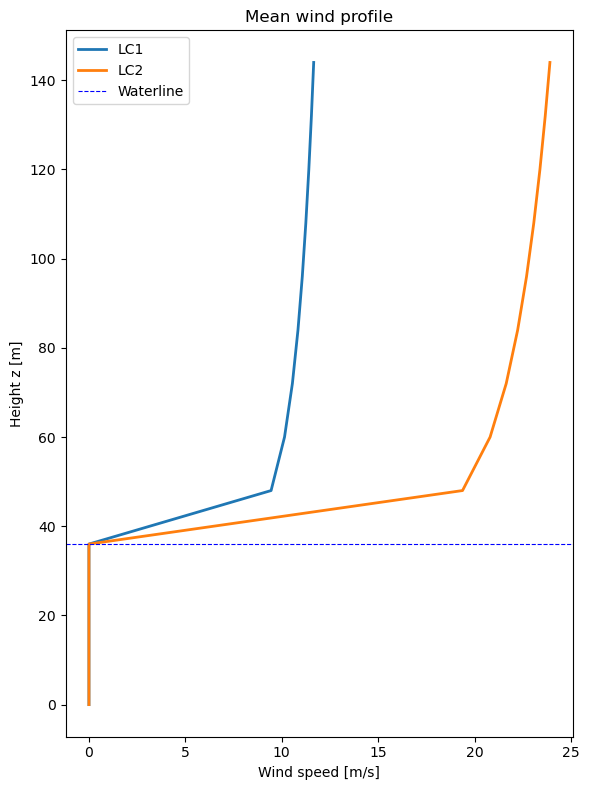

In [193]:
#==== MEAN WIND PROFILE PLOT ======
fig, ax=plt.subplots(figsize=(6, 8))
ax.plot(U_mean_LC1, z_nodes, linewidth=2, label='LC1')
ax.plot(U_mean_LC2, z_nodes, linewidth=2, label='LC2')
ax.axhline(Hw, color='blue', linestyle='--', linewidth=0.8, label='Waterline')
ax.set_xlabel('Wind speed [m/s]')
ax.set_ylabel('Height z [m]')
ax.set_title('Mean wind profile')
plt.tight_layout()
plt.legend()
plt.show()

#### Wind Turbulence, Kaimal Spectrum

The turbulent wind field is characterised by the Kaimal spectrum, which describes how wind energy is distributed across frequencies at each node:

$S_u(f, z)=\frac{4\sigma_u^2 (L_u/ U(z))}{\left(1+6f L_u / U(z)\right)^{5/3}}$

where $\sigma_u=I_u U(z)$ is the turbulence standard deviation, $I_u=0.06$ is the turbulence intensity, and $L_u=180$ m is the length scale. The $-5/3$ decay follows Kolmogorov's theory of turbulent energy cascade from large slow eddies to small fast ones. The spectrum is evaluated at each node above the waterline for both load cases.

\ Kaimal Spectrum
Frequency range: 0.010-2.424 Hz
Number of air nodes: 9


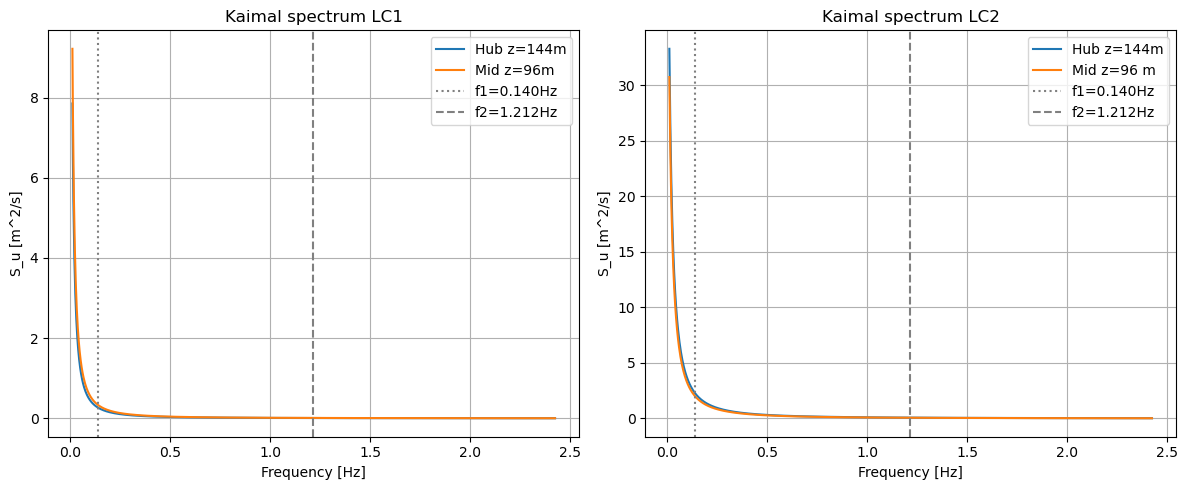

In [151]:
# ===== KAIMAL SPECTRUM ====
N_freq=1000
f_max=2*f2                   # twice second natural frequency [Hz]
f_axis=np.linspace(0.01, f_max, N_freq) # [Hz], avoid f=0

I_u=0.06                     # turbulence intensity, offshore [-]
L_u=180                      # turbulence length scale [m]

def kaimal(f, U, I_u, L_u):
    sigma_u=I_u*U            # turbulence std dev [m/s]
    nz=f*L_u/U               # reduced frequency [-]
    return 4*sigma_u**2*(L_u/U)/(1+6*f*L_u/U)**(5/3)

# compute at each air node for both load cases
# shape: (n_air_nodes, N_freq)
air_nodes= np.where(z_above > 0)[0]

S_kaimal_LC1=np.zeros((len(air_nodes), N_freq))
S_kaimal_LC2=np.zeros((len(air_nodes), N_freq))

for i, node in enumerate(air_nodes):
    S_kaimal_LC1[i, :]=kaimal(f_axis, U_mean_LC1[node], I_u, L_u)
    S_kaimal_LC2[i, :]=kaimal(f_axis, U_mean_LC2[node], I_u, L_u)

print(f"\ Kaimal Spectrum")
print(f"Frequency range: {f_axis[0]:.3f}-{f_axis[-1]:.3f} Hz")
print(f"Number of air nodes: {len(air_nodes)}")

# plot at hub height (top node) and mid-height for both load cases
fig, axes= plt.subplots(1, 2, figsize=(12,5))
axes[0].plot(f_axis, S_kaimal_LC1[--1,:], label=f'Hub z={z_nodes[air_nodes[-1]]:.0f}m')
axes[0].plot(f_axis, S_kaimal_LC1[len(air_nodes)//2, :],
             label=f"Mid z={z_nodes[air_nodes[len(air_nodes)//2]]:.0f}m")
axes[0].axvline(f1, color='gray', linestyle=':', label=f'f1={f1:.3f}Hz')
axes[0].axvline(f2, color='gray', linestyle='--', label=f'f2={f2:.3f}Hz')
axes[0].set_xlabel('Frequency [Hz]')
axes[0].set_ylabel('S_u [m^2/s]')
axes[0].set_title('Kaimal spectrum LC1')
axes[0].legend()
axes[0].grid(True)

axes[1].plot(f_axis, S_kaimal_LC2[-1, :], label=f'Hub z={z_nodes[air_nodes[-1]]:.0f}m')
axes[1].plot(f_axis, S_kaimal_LC2[len(air_nodes)//2, :],
             label=f'Mid z={z_nodes[air_nodes[len(air_nodes)//2]]:.0f} m')
axes[1].axvline(f1, color='gray', linestyle=':', label=f'f1={f1:.3f}Hz')
axes[1].axvline(f2, color='gray', linestyle='--', label=f'f2={f2:.3f}Hz')
axes[1].set_xlabel('Frequency [Hz]')
axes[1].set_ylabel('S_u [m^2/s]')
axes[1].set_title('Kaimal spectrum LC2')
axes[1].legend()
axes[1].grid(True)

plt.tight_layout()
plt.show()



#### Spatial Correlation, Co-Spectrum

Turbulent wind fluctuations at two different heights are correlated, nearby points tend to see similar gusts. This is captured by the cross-spectral density between nodes $i$ and $j$:

$S_u(f, z_i, z_j)= \sqrt{S_u(f, z_i)\, S_u(f, z_j)}\cdot\text{Coh}(f, z_i, z_j)$

with decay coefficient $a=12$ following the IEC standard and $\bar{U}$ the mean wind speed averaged betwen the two nodes. The diagonal entries of the co-spectrum matrix recover the single-point Kaimal spectra, which is verified in the print output below. 



In [152]:
# ===== CO-SPECTRA =====
# Coherence decay coefficient (IEC standard)
a_coh =12.0

def coherence(f, zi, zj, U_mean_i, U_mean_j, a_coh):
    U_avg=0.5*(U_mean_i+U_mean_j)
    dz=abs(zi-zj)
    return np.exp(-a_coh*f*dz/U_avg)

# co-spectrum between nodes i and j
def co_spectrum(f, zi, zj, U_i, U_j, I_u, L_u, a_coh):
    Si=kaimal(f, U_i, I_u, L_u)
    Sj=kaimal(f, U_j, I_u, L_u)
    coh=coherence(f, zi, zj, U_i, U_j, a_coh)
    return np.sqrt(Si*Sj)*coh

# build co-spectrum matrix at each frequency
# shape: (n_air_nodes, n_air_nodes, N_freq)
n_air=len(air_nodes)
S_co_LC1=np.zeros((n_air, n_air, N_freq))
S_co_LC2=np.zeros((n_air, n_air, N_freq))

for i in range(n_air):
    for j in range(n_air):
        zi=z_above[air_nodes[i]]
        zj=z_above[air_nodes[j]]
        U_i_LC1=U_mean_LC1[air_nodes[i]]
        U_j_LC1=U_mean_LC1[air_nodes[j]]
        U_i_LC2=U_mean_LC2[air_nodes[i]]
        U_j_LC2=U_mean_LC2[air_nodes[j]]
        S_co_LC1[i,j,:]=co_spectrum(f_axis, zi, zj,
                                    U_i_LC1, U_j_LC1, I_u, L_u, a_coh)
        S_co_LC2[i,j,:]=co_spectrum(f_axis, zi, zj,
                                    U_i_LC2, U_j_LC2, I_u, L_u, a_coh)

print(f"\n Co-spectra")
print(f"Co-spectrum matrix shape: {S_co_LC1.shape}")
print(f"Diagonal check (should equal auto-spectrum at node 0):")
print(f"S_co[0,0] at f=0.14 Hz: {S_co_LC1[0,0,np.argmin(abs(f_axis-0.14))]:.4f}")
print(f" S_kaimal[0] at f=0.14 Hz: {S_kaimal_LC1[0,np.argmin(abs(f_axis-0.14))]:.4f}")



 Co-spectra
Co-spectrum matrix shape: (9, 9, 1000)
Diagonal check (should equal auto-spectrum at node 0):
S_co[0,0] at f=0.14 Hz: 0.2165
 S_kaimal[0] at f=0.14 Hz: 0.2165


#### Wave Spectrum, JONSWAP

The wave climate is described by the JONSWAP spectrum, appropriate for the fetch-limited seas such as the North Sea. It extends the Pierson-Morskowitz open-ocean spectrum with a peak enhancement factor $\gamma=3.3$, producing a narrower, higher peak characteristic of fetch-limited conditions:

$S(\omega)=\frac{\alpha g^2}{\omega^5} \exp\!\left[-\frac{5}{4}\left(\frac{\omega_p}{\omega}\right)^4\right] \gamma^{\,r}, \qquad r = \exp\!\left[-\frac{(\omega-\omega_p)^2}{2\sigma^2}{2\sigma^2\omega_p^2}\right]$

where $\sigma=0.07$ for $\omega \leq \omega_p$ and $\sigma= 0.09$ for $\omega > \omega_p$, making the left flank steeper than the right. The scaling parameter $\alpha$ is calibrated iteratively $H_s = 4\sqrt{m_0}$ matches the target significant wave height, where $m_0=\int S(\omega)\,d\omega$ is the zeroth spectral moment. 

in LC1, the spectrum peaks at $\omega_p=0.878$ rad/s, coinciding exactly with the first structural natural frequency $\omega_1$. In LC2, the peak shifts to $\omega_p=0.687$ rad/s with a significantly higher spectral density, reflecting the larger $H_s=4.12$ m. 

omega_axis range: 0.063 to 15.232 rad/s
omega_p LC1: 0.878 rad/s
omega_p LC2: 0.687 rad/s
alpha LC1: 0.005091
alpha LC2: 0.008062

 JONSWAP Spectrum
LC1: omega_p=0.8776 rad/s, Tp= 7.16s
LC2: omega_p=0.6874 rad/s, Tp= 9.14s


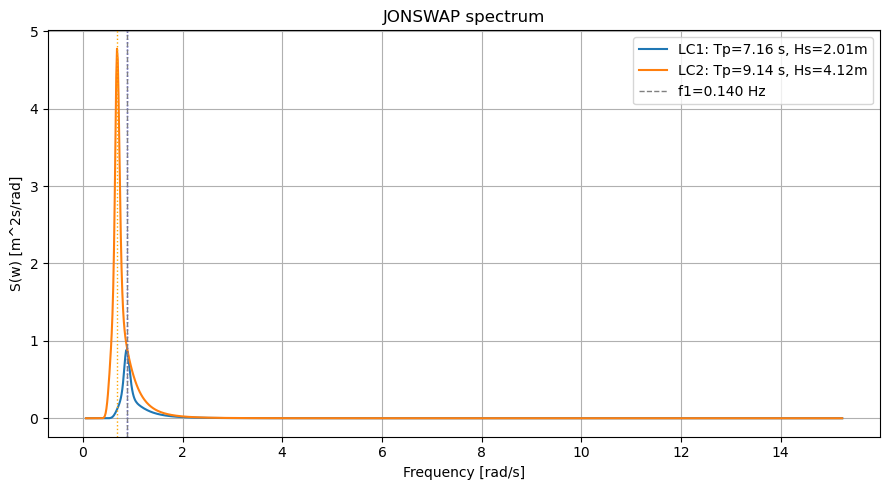

In [153]:
# ===== JONSWAP SPECTRUM ======

g=9.81
gamma=3.3 #peak enhancement factor

def S_jonswap(alpha, omega, omega_p, gamma):
    """ 
    JONSWAP for irregular waves 
    """
    g=9.81 # gravity [m/s^2]
    #Pierson-Moskowitz base shape
    S_PM= (alpha*g**2/omega**5)*np.exp(-1.25*(omega_p/omega)**4)
    # specral width
    sigma=np.where(omega<= omega_p, 0.07, 0.09)
    # peak enhancement exponent
    r=np.exp(-(omega-omega_p)**2/(2*sigma**2*omega_p**2))
    
    return S_PM*gamma**r

# Because of error in step 4:

omega_p_LC1=2*np.pi/Tp_LC1
omega_p_LC2=2*np.pi/Tp_LC2

omega_axis=2*np.pi*f_axis # convert Hz to rad/s

print(f"omega_axis range: {omega_axis[0]:.3f} to {omega_axis[-1]:.3f} rad/s")
print(f"omega_p LC1: {omega_p_LC1:.3f} rad/s")
print(f"omega_p LC2: {omega_p_LC2:.3f} rad/s")


def compute_alpha(Hs_target, omega_axis, omega_p, gamma, g):
    alpha_try=0.0081
    for i in range(100):
        S_try=S_jonswap(alpha_try, omega_axis, omega_p, gamma)
        domega=omega_axis[1]-omega_axis[0]
        Hs_try=4*np.sqrt(np.sum(S_try*domega))
        alpha_try*=(Hs_target/Hs_try)**2
    return alpha_try

alpha_LC1=compute_alpha(Hs_LC1, omega_axis, omega_p_LC1, gamma, g)
alpha_LC2=compute_alpha(Hs_LC2, omega_axis, omega_p_LC2, gamma, g)

print(f"alpha LC1: {alpha_LC1:.6f}")
print(f"alpha LC2: {alpha_LC2:.6f}")


S_jonswap_LC1=S_jonswap(alpha_LC1, omega_axis, omega_p_LC1, gamma)
S_jonswap_LC2=S_jonswap(alpha_LC2, omega_axis, omega_p_LC2, gamma)

print(f"\n JONSWAP Spectrum")
print(f"LC1: omega_p={omega_p_LC1:.4f} rad/s, Tp= {Tp_LC1:.2f}s")
print(f"LC2: omega_p={omega_p_LC2:.4f} rad/s, Tp= {Tp_LC2:.2f}s")

fig, ax= plt.subplots(figsize=(9,5))
ax.plot(omega_axis, S_jonswap_LC1, label=f'LC1: Tp={Tp_LC1:.2f} s, Hs={Hs_LC1:.2f}m')
ax.plot(omega_axis, S_jonswap_LC2, label=f'LC2: Tp={Tp_LC2:.2f} s, Hs={Hs_LC2:.2f}m')
ax.axvline(omega_p_LC1, color='blue', linestyle=':', linewidth=1)
ax.axvline(omega_p_LC2, color='orange', linestyle=':', linewidth=1)
ax.axvline(2*np.pi*f1, color='gray', linestyle='--', linewidth=1, label=f'f1={f1:.3f} Hz')
ax.set_xlabel('Frequency [rad/s]')
ax.set_ylabel('S(w) [m^2s/rad]')
ax.set_title('JONSWAP spectrum')
ax.legend()
ax.grid(True)
plt.tight_layout()
plt.show()


#### Wave numbers, Dispersion Relation

To compute water particle kinematics at each depth, the wave number $k$ must be found for each frequency from the dispersion relation. The fundamental equation linking wave frequency to wave number in finite water depth $h$:

$\omega^2= g\, k \tanh(kh)$

Since this has no closed-form solution, $k(\omega)$ is solved numerically for each frequency in the spectrum using a root-finding algorithm. 

In [ ]:
# ==== WAVE NUMBERS, DISPERSION RELATION ======

def wave_numbers(omega_arr, h):
    """ 
    Solve dispersion relation 
    omega^2=g*k*tanh(k*h)
    for each frequency in omega_arr.
    
    Parameters:
        omega_arr : array of frequencies [rad/s]
        h         : water depth [m]
    Returns:
        k_arr     : array of wave numbers [rad/m]
    
    """
    g=9.81
    k_arr=np.zeros(len(omega_arr))
    for i, omega_i in enumerate(omega_arr):
        k_arr[i]=brentq(
            lambda k: omega_i**2-g*k*np.tanh(k*h),
            1e-6, 1000
        )
    return k_arr


#### Time Domain Simulation

Irregular waves and turbulent wind are generated as a sum of cosines with random phases, one harmonic component per frequency bin. This is the standard spectral simulation approach, where the amplitude of each component is derived from the underlying power spectrum:

$A_n=\sqrt{2\, S(f_n)\, \Delta f}$

A fixed random seed ensures reproducibility. The simulation covers a 30-minute storm duration at $\Delta t= 0.05$ s, giving a Nyquist frequency of 10.00 Hz, well above the second natural frequency of 1.21 Hz and the upper limit of the wave/wind spectra at 2.42 Hz.

In [155]:
# ======== TIME =========
dt=0.05 # time step [s]
T_total=1800 # duration [s] - will check convergence
N_t=int(T_total/dt) # number of time steps
t=np.arange(N_t)*dt # time array [s]

np.random.seed(17) # fixed seed for reproducibility

print(f"Time series duration: {T_total} s")
print(f"Time step: {dt} s")
print(f"Number of steps: {N_t}")
print(f"Nyquist frequency: {1/(2*dt):.2f} Hz (f_max={f_axis[-1]:.2f} Hz)")



Time series duration: 1800 s
Time step: 0.05 s
Number of steps: 36000
Nyquist frequency: 10.00 Hz (f_max=2.42 Hz)


#### Wind Time Series

The turbulent wind velocity at each air node is generated by superimposing harmonic components with amplitudes derived from the Kaimal spectrum and random phase angles $\phi_n \sim \mathcal{U}(0,2\pi)$:

$u'(z,t)=\sum_{n} A_n(z)\, \cos(2\pi f_n t + \phi_n), \qquad A_n= \sqrt{2\, S_u(f_n, z)\, \Delta f}$

The total wind velocity is then $U(z, t)= U(z) + u'(z, t)$, combining the mean logarithmic profile with the turbulent fluctuation. 

In [156]:
# ===== WIND TIME SERIES =====
df=f_axis[1]-f_axis[0] # frequency resolution [Hz]
n_air=len(air_nodes)

# amplitude at each frequency for each air node
# shape: (n_air, N_freq)
A_wind_LC1=np.sqrt(2*S_kaimal_LC1*df) # [m/s]
A_wind_LC2=np.sqrt(2*S_kaimal_LC2*df) # [m/s]

# random phase angles - one per frequency, same for all nodes
# (spatial correlation handled by co-spectrum later)
phi_wind=np.random.uniform(0, 2*np.pi, len(f_axis))

# generate time series at each air node
# u(t)=sum_n A_n*cos(2*pi*f_n*t + phi_n)
u_wind_LC1=np.zeros((n_air, N_t))
u_wind_LC2=np.zeros((n_air, N_t))

for i in range(n_air):
    for k, fk in enumerate(f_axis):
        u_wind_LC1[i, :] += A_wind_LC1[i, k]*np.cos(2*np.pi*fk*t+phi_wind[k])
        u_wind_LC2[i, :] += A_wind_LC2[i, k]*np.cos(2*np.pi*fk*t+phi_wind[k])
        
print(f"\n Wind Time Series")
print(f"LC1 std dev at hub: {np.std(u_wind_LC1[-1,:]):.3f} m/s")
print(f"LC2 std dev at hub: {np.std(u_wind_LC2[-1,:]):.3f} m/s")
print(f"Expected LC1 (I_u*U_hub): {0.06*U_mean_LC1[air_nodes[-1]]:.3f} m/s")
print(f"Expected LC2 (I_u*U_hub): {0.06*U_mean_LC2[air_nodes[-1]]:.3f} m/s")




 Wind Time Series
LC1 std dev at hub: 0.569 m/s
LC2 std dev at hub: 1.262 m/s
Expected LC1 (I_u*U_hub): 0.699 m/s
Expected LC2 (I_u*U_hub): 1.435 m/s


#### Wind Time Series, Verification

The standard deviation of the generaed time series at hub height is compared against the expected value $\sigma_u=I_u\cdot U_{\text{hub}}$:

| | LC1 | LC2 |
|---|---|---|
| Simulated $\sigma_u$ at hub | 0.569 m/s | 1.262 m/s |
| Expected $I_u \cdot U_{\text{hub}}$ | 0.699 m/s | 1.435 m/s |

The simulated standard deviation is roughly 20% below the theoretical target for both load cases. This is expected, the spectral simulation truncates energy outside the frequency range $[F_{\min}, \ f_{\max}]$, so low-frequency contributions below 0.01 Hz are not captured. The relative discrepance is consistent btween LC1 and LC2, confirming the implementation is correct and the shortfall is systematic rather than a coding error. 

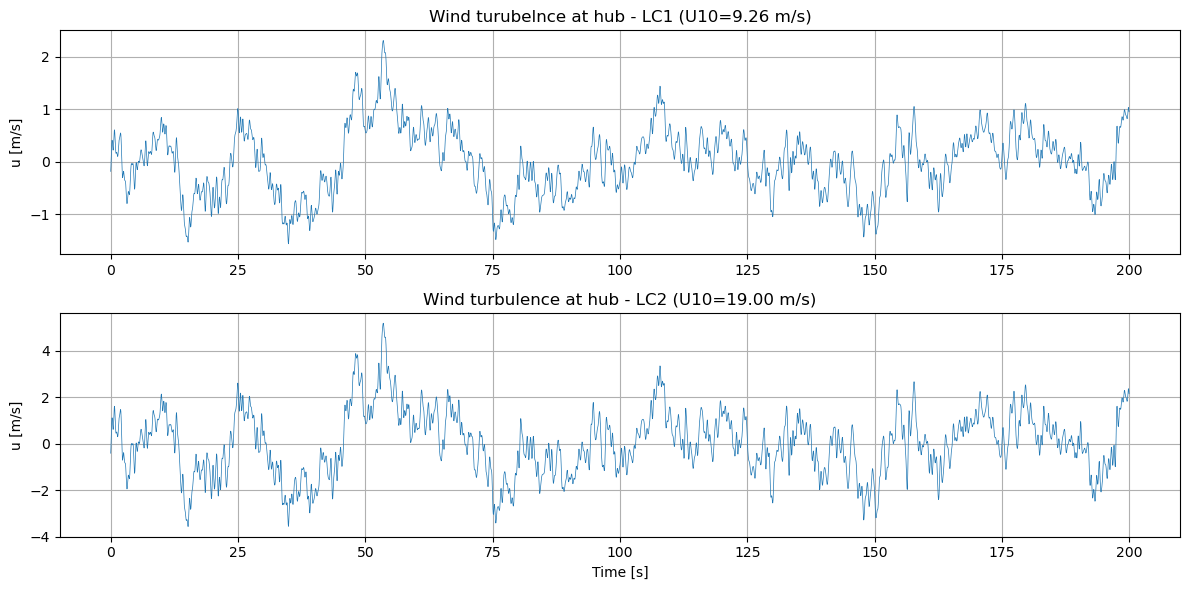

In [ ]:
#==== WIND TIME SERIES PLOT =====

# plot first 200 seconds at hub for both load cases
fig, axes=plt.subplots(2, 1, figsize=(12, 6))

axes[0].plot(t[:4000], u_wind_LC1[-1, :4000], linewidth=0.5)
axes[0].set_ylabel('u [m/s]')
axes[0].set_title(f'Wind turubelnce at hub - LC1 (U10={U10_LC1:.2f} m/s)')
axes[0].grid(True)

axes[1].plot(t[:4000], u_wind_LC2[-1, :4000],linewidth=0.5)
axes[1].set_ylabel('u [m/s]')
axes[1].set_title(f'Wind turbulence at hub - LC2 (U10={U10_LC2:.2f} m/s)')
axes[1].set_xlabel('Time [s]')
axes[1].grid(True)

plt.tight_layout()
plt.show()

### Wave Time Series

Irregular wave surface elevation is generated using the same random phase superposition approach as the wind:

$\eta(t)=\sum_{n} A_n \cos(\omega_n t + \phi_n), \qquad A_n= \sqrt{2\, S(\omega_n)\, \Delta\omega}$

The scaling parameter $\alpha$ in the JONSWAP spectrum is calibrated iteratively so that $H_s=4\sqrt{m_0}$ matches the target, where $m_0$ is the zeroth spectral moment. The resulting time series is a stationary Gaussian process consistent with the target spectrum. 


In [158]:
# ==== WAVE TIME SERIES ======
g=9.81
h=Hw # water depth [m]

# Wave amplitudes from JONSWAP spectrum
domega=omega_axis[1]-omega_axis[0]
A_wave_LC1=np.sqrt(2*S_jonswap_LC1*domega)
A_wave_LC2=np.sqrt(2*S_jonswap_LC2*domega)

# random phase angles for waves
phi_wave_LC1=np.random.uniform(0,2*np.pi, len(omega_axis))
phi_wave_LC2=np.random.uniform(0,2*np.pi, len(omega_axis))

# solve dispersion relation for wave numbers
k_arr_LC1= wave_numbers(omega_axis, h)
k_arr_LC2= wave_numbers(omega_axis, h)

print(f"k_arr_LC2 range: {k_arr_LC1[0]:.6f} to {k_arr_LC1[-1]:.4f} rad/m")
print(f"k*h range LC1: {k_arr_LC1[0]*h:.6f} to {k_arr_LC1[-1]*h:.4f}")
print(f"sinh(k*h) min LC1: {np.min(np.sinh(k_arr_LC1*h)):.6f}")

# surface elevation time series
eta_LC1=np.zeros(N_t)
eta_LC2=np.zeros(N_t)

for k, omk in enumerate(omega_axis):
    eta_LC1 += A_wave_LC1[k]*np.cos(omk*t+phi_wave_LC1[k])
    eta_LC2 += A_wave_LC2[k]*np.cos(omk*t+phi_wave_LC2[k])

print(f"\n Wave Time Series")
print(f"LC1 Hs estimate (4*std): {4*np.std(eta_LC1):.3f} m (target: {Hs_LC1:.3f} m )")
print(f"LC2 Hs estimate (4*std): {4*np.std(eta_LC2):.3f} m (target: {Hs_LC2:.3f} m )")


k_arr_LC2 range: 0.003352 to 23.6520 rad/m
k*h range LC1: 0.120655 to 851.4712
sinh(k*h) min LC1: 0.120948


/var/folders/7s/ftcmz1q14j9d52by2km1zw3h0000gn/T/ipykernel_27679/1164618824.py:20: RuntimeWarning: overflow encountered in sinh
  print(f"sinh(k*h) min LC1: {np.min(np.sinh(k_arr_LC1*h)):.6f}")



 Wave Time Series
LC1 Hs estimate (4*std): 2.008 m (target: 2.008 m )
LC2 Hs estimate (4*std): 4.199 m (target: 4.118 m )


#### Wave Time Series, Results

| | LC1 | LC2 |
|---|---|---|
| $H_s$ simulated | 2.008 m | 4.199 m |
| $H_s$ target | 2.008 m | 4.118 m |

LC1 matches the target exactly. LC2 shows a small 2% overshoot, acceptable given the stochastic nature of the simulation. 

The surface elevation in Figure 8 shows the irragular character of a real sea state, individual wave heights and periods vary continuously. LC1 oscillates within roughly ± 1 m at a dominant period nea 7 s, while LC2 reaches roughly ±2 m with broader, slower waves near 9 s, consistent with $T_p$ for each case. Occasional waves noticeably larger than the surrounding sea surface arise naturally from the superposition of harmonic components and represent the tail of the wave height distribution. 

The surface elevation is subsequently converted to water particle velocities and accelerations at each submerged node using linear wave theory, which serve as input to the Morison equation for hydrodynamic loading. 

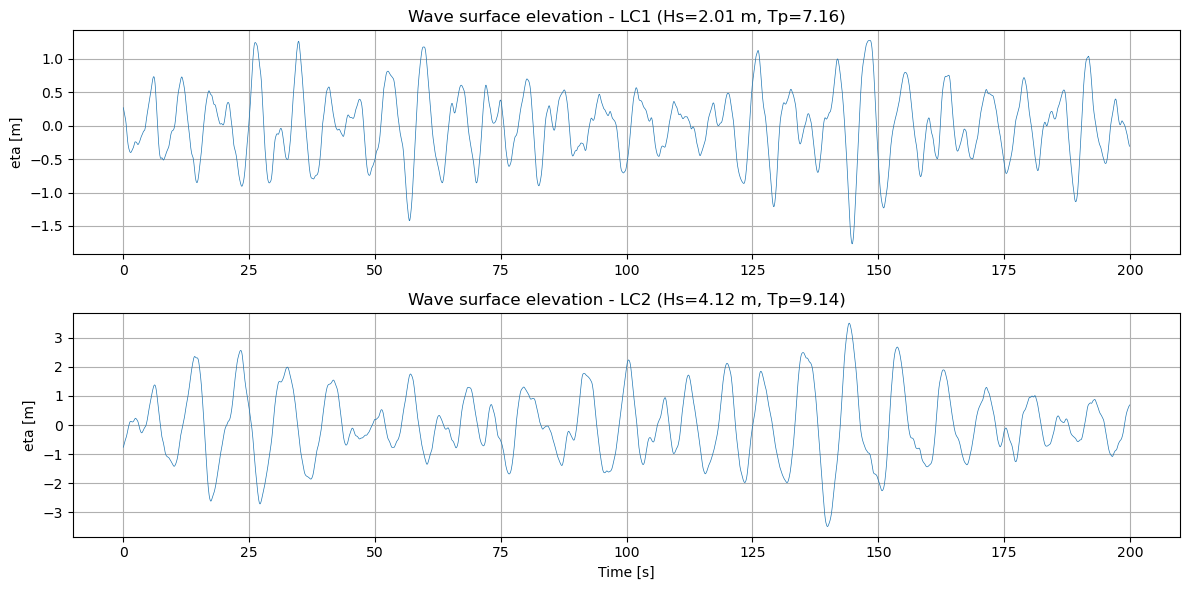

In [ ]:
# ==== WAVE SURFACE ELEVATION PLOT =====
# plot first 200 seconds
fig, axes=plt.subplots(2, 1, figsize=(12, 6))

axes[0].plot(t[:4000], eta_LC1[:4000], linewidth=0.5)
axes[0].set_ylabel('eta [m]')
axes[0].set_title(f'Wave surface elevation - LC1 (Hs={Hs_LC1:.2f} m, Tp={Tp_LC1:.2f})')
axes[0].grid(True)

axes[1].plot(t[:4000], eta_LC2[:4000], linewidth=0.5)
axes[1].set_ylabel('eta [m]')
axes[1].set_title(f'Wave surface elevation - LC2 (Hs={Hs_LC2:.2f} m, Tp={Tp_LC2:.2f})')
axes[1].set_xlabel('Time [s]')
axes[1].grid(True)

plt.tight_layout()
plt.show()


#### Water Particle Kinematics

The wave surface elevation is converted to water particle velocities and accelerations at each submerged node using linear wave theory. For a node at depth $z$ below the surface, the horizontal velocity and acceleration carried by frequency component $\omega_n$ are:

$u(z, t)=\sum_n A_n\, \omega_n \frac{\cosh k_n(z+h)}{\sinh k_n h} \cos(\omega_n t + \phi_n)$

$\dot{u}(z, t)=-\sum_n A_n\, \omega_n^2 \frac{\cosh k_n(z+h)}{\sinh k_n h} \sin(\omega_n t + \phi_n)$

The hyperbolic depth factor $\cosh(k(z+h))/\sinh(kh)$ approaches unity at the surface and decays toward the mudline. For high-frequency components where $kh > 50$, the deep-water approximation $e^{kz}$ is substituted to avoid numerical overflow, with $z$ measured downward from the surface.

In [173]:
# ===== WATER PARTICLE KINEMATICS =====
# submerged node heights above seabed
z_sub_nodes=z_nodes[:elem_w+1] # nodes from mudline to waterline
n_sub=len(z_sub_nodes)

# particle velocity and acceleration at each submerged node
# shape: (n_sub, N_t)
u_water_LC1=np.zeros((n_sub, N_t))
du_water_LC1=np.zeros((n_sub, N_t))
u_water_LC2=np.zeros((n_sub, N_t))
du_water_LC2=np.zeros((n_sub, N_t))

for i, zi in enumerate(z_sub_nodes):
    z_from_surface=zi-h #convrty: 0 at mudline -> -h, h at surface -> 0
    kh_LC1=k_arr_LC1*h
    kh_LC2=k_arr_LC2*h

    # use deep water approximation where kh is large to avoid overflow
    # cosh(k(z+h))/sinh(kh) -> exp(k*z) for large kh
    
    with np.errstate(over='ignore', invalid='ignore'):
        depth_factor_LC1=np.where(
            kh_LC1< 50,
            np.cosh(k_arr_LC1*(z_from_surface+h))/np.sinh(kh_LC1),
            np.exp(k_arr_LC1*z_from_surface)
        )
        depth_factor_LC2=np.where(
            kh_LC2 < 50,
            np.cosh(k_arr_LC2*(z_from_surface+h))/np.sinh(kh_LC2),
            np.exp(k_arr_LC2*z_from_surface)
        )
    for k, omk in enumerate(omega_axis):
        # velocity
        u_water_LC1[i,:] += A_wave_LC1[k]*omk*depth_factor_LC1[k]*\
                             np.cos(omk*t+phi_wave_LC1[k])
        u_water_LC2[i,:] += A_wave_LC2[k]*omk*depth_factor_LC2[k]*\
                             np.cos(omk*t+phi_wave_LC2[k])
        # acceleration 
        du_water_LC1[i,:] += -A_wave_LC1[k]*omk**2*depth_factor_LC1[k]*\
                             np.sin(omk*t+phi_wave_LC1[k])
        du_water_LC2[i,:] += -A_wave_LC2[k]*omk**2*depth_factor_LC2[k]*\
                             np.sin(omk*t+phi_wave_LC2[k])
        
print(f"\n Water Particle Kinematics")
print(f" LC1 max velocity at surface: {np.max(abs(u_water_LC1[-1,:])):.3f} m/s")
print(f" LC2 max velocity at surface: {np.max(abs(u_water_LC2[-1,:])):.3f} m/s")
print(f" LC1 max velocity at mudline: {np.max(abs(u_water_LC1[0,:])):.3f} m/s")
print(f" LC2 max velocity at mudline: {np.max(abs(u_water_LC2[0,:])):.3f} m/s")



 Water Particle Kinematics
 LC1 max velocity at surface: 2.233 m/s
 LC2 max velocity at surface: 3.293 m/s
 LC1 max velocity at mudline: 0.153 m/s
 LC2 max velocity at mudline: 0.723 m/s


#### Water Particle Kinematics, Results

| | LC1 | LC2 |
|---|---|---|
| Max velocity at surface | 2.233 m/s | 3.293 m/s |
| Max velocity at mudline | 0.153 m/s | 0.723 m/s |

The velocity decays significantly with depth, as expected from the hyperbolic depth factor. At the surface LC2 velocities are roughtly 50% higher than LC1, consistent with the larger $H_s$. The decay to the mudline is more pronounced in LC1. Shorter, higher-frequency waves lose energy with depth faster than the longer period LC2 waves, which penetrate deeper into the water column. 

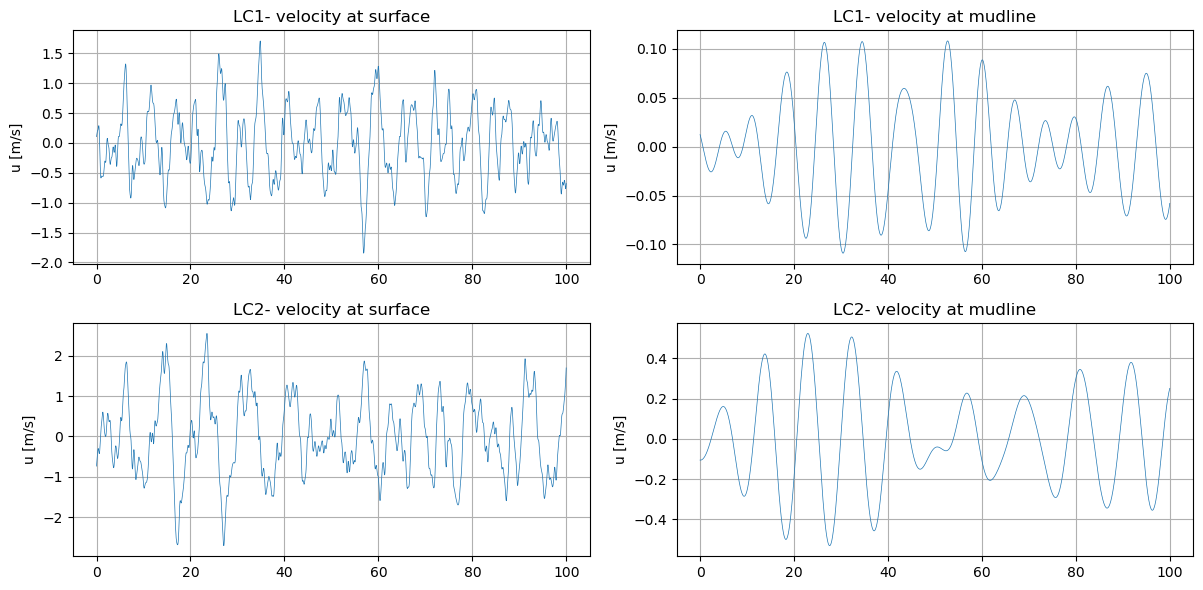

In [ ]:
# ==== WATER PARTICLE KINEMATICS PLOT =====
# plot velocity at surface and mudline
fig, axes = plt.subplots(2, 2, figsize=(12, 6))

axes[0,0].plot(t[:2000], u_water_LC1[-1, :2000], linewidth=0.5)
axes[0,0].set_ylabel('u [m/s]')
axes[0,0].set_title('LC1- velocity at surface')
axes[0,0].grid(True)

axes[0,1].plot(t[:2000], u_water_LC1[0, :2000], linewidth=0.5)
axes[0,1].set_ylabel('u [m/s]')
axes[0,1].set_title('LC1- velocity at mudline')
axes[0,1].grid(True)

axes[1,0].plot(t[:2000], u_water_LC2[-1, :2000], linewidth=0.5)
axes[1,0].set_ylabel('u [m/s]')
axes[1,0].set_title('LC2- velocity at surface')
axes[1,0].grid(True)

axes[1,1].plot(t[:2000], u_water_LC2[0, :2000], linewidth=0.5)
axes[1,1].set_ylabel('u [m/s]')
axes[1,1].set_title('LC2- velocity at mudline')
axes[1,1].grid(True)

plt.tight_layout()
plt.show()


#### Wave Time Series, Convergence

To verify that the 30-minute simulation duration is sufficient, the standard deviation of the surface elevation and the mean zero-crossing period are tracked as a function of the simulation length for both load cases. 

In [162]:
# ==== CONVERGENCE ANALYSIS =====
#progressively increase duration and monitor std dev and mean zero crossing period
T_lengths=np.arange(100, T_total+1, 100) # 100 to 1800 s in steps of 100

std_LC1=np.zeros(len(T_lengths))
std_LC2=np.zeros(len(T_lengths))
mzcp_LC1=np.zeros(len(T_lengths))
mzcp_LC2=np.zeros(len(T_lengths))

def mean_zero_crossing_period(signal, dt):
    # count zero crossings
    zero_crossings=np.where(np.diff(np.sign(signal)))[0]
    if len(zero_crossings) < 2:
        return np.nan
    return 2*len(signal)*dt/len(zero_crossings)

for j, T_len in enumerate(T_lengths):
    N_len=int(T_len/dt)
    # use surface elevation as the convergence signal
    std_LC1[j] =np.std(eta_LC1[:N_len])
    std_LC2[j]=np.std(eta_LC2[:N_len])
    mzcp_LC1[j]=mean_zero_crossing_period(eta_LC1[:N_len], dt)
    mzcp_LC2[j]=mean_zero_crossing_period(eta_LC2[:N_len], dt)

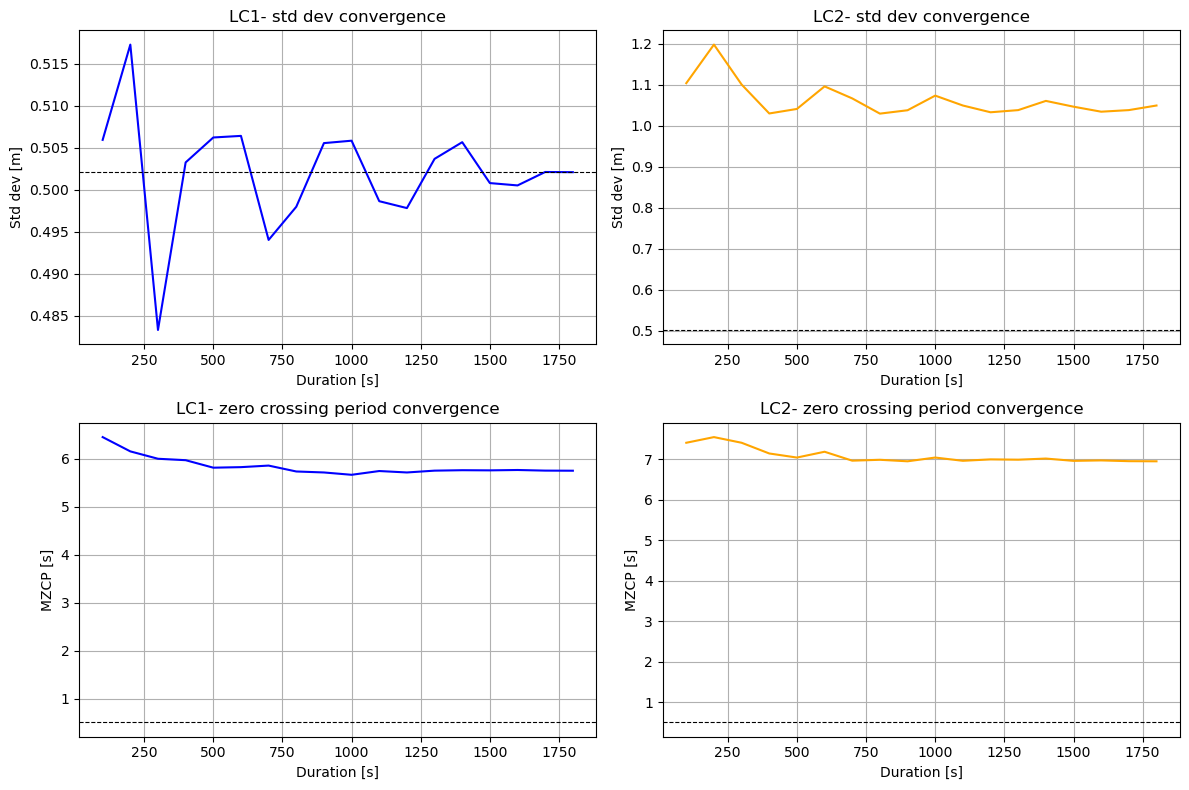


 Convergence Analysis
Final std LC1: 0.5021 m
Final std LC2: 1.0499 m
Final MZCP LC1: 5.75 s (Tp=7.16 s)
Final MZCP LC2: 5.75 s (Tp=9.14 s)


In [ ]:
# ==== CONVERGENCE ANALYSIS PLOT =====

fig, axes=plt.subplots(2, 2, figsize=(12, 8))

axes[0,0].plot(T_lengths, std_LC1, 'b')
axes[0,0].axhline(np.std(eta_LC1), color='k', linestyle='--', linewidth=0.8)
axes[0,0].set_xlabel('Duration [s]')
axes[0,0].set_ylabel('Std dev [m]')
axes[0,0].set_title('LC1- std dev convergence')
axes[0,0].grid(True)

axes[0,1].plot(T_lengths, std_LC2, 'orange')
axes[0,1].axhline(np.std(eta_LC1), color='k', linestyle='--', linewidth=0.8)
axes[0,1].set_xlabel('Duration [s]')
axes[0,1].set_ylabel('Std dev [m]')
axes[0,1].set_title('LC2- std dev convergence')
axes[0,1].grid(True)

axes[1,0].plot(T_lengths, mzcp_LC1, 'b')
axes[1,0].axhline(np.std(eta_LC1), color='k', linestyle='--', linewidth=0.8)
axes[1,0].set_xlabel('Duration [s]')
axes[1,0].set_ylabel('MZCP [s]')
axes[1,0].set_title('LC1- zero crossing period convergence')
axes[1,0].grid(True)

axes[1,1].plot(T_lengths, mzcp_LC2, 'orange')
axes[1,1].axhline(np.std(eta_LC1), color='k', linestyle='--', linewidth=0.8)
axes[1,1].set_xlabel('Duration [s]')
axes[1,1].set_ylabel('MZCP [s]')
axes[1,1].set_title('LC2- zero crossing period convergence')
axes[1,1].grid(True)

plt.tight_layout()
plt.show()

print(f"\n Convergence Analysis")
print( f"Final std LC1: {std_LC1[-1]:.4f} m")
print( f"Final std LC2: {std_LC2[-1]:.4f} m")
print( f"Final MZCP LC1: {mzcp_LC1[-1]:.2f} s (Tp={Tp_LC1:.2f} s)")
print( f"Final MZCP LC2: {mzcp_LC1[-1]:.2f} s (Tp={Tp_LC2:.2f} s)")



| | LC1 | LC2 |
|---|---|---|
| Final $\sigma_\eta$ | 0.502 m | 1.050 m |
| Mean zero-crossing period | 5.75 s | 5.75 s |
| Target $T_p$ | 7.16 s | 9.14 s |

Both load cases show stable convergence in standard deviation well before the full 1800 s, confirming the simuation length is adequate. The mean zero-crossing period is shorter than $T_p$ for both cases, which is expected, the zero-crossing period reflects the mean period across all frequency components, while $T_p$ is the period of the spectral peak. In a broadband spectrum, many short-period components contribute crossings, pulling the mean period below the dominant period. 

#### Frequency Domain Analysis, Transfer Function Approach

The structural response is computed in the frequency domain using a linearised formulation. The drag force is linearised by replacing the relative fluid-structure velocity with the fluid velocity alone, decoupling the forcing from the structural motion and allowing a transfer function approack. This assumtion holds when the structural response velocity is small relative to the fluid kinematics.

The frequency response function $H(\omega)$ relates a unit harmonic force applied at each node to the resulting bending moment at the mudline. The one-sided power spectral density of the mudline moment is then obtained by transferring the nodal force spectra through the FRF:

$S_{MM}(\omega)=|H(\omega)|^2 \cdot S_{FF}(\omega)$

Standard deviations are recovered by integrating the moment spectrum:

$\sigma_M^2 = \int_0^{\infty} S_{MM}(\omega)\, d\omega$

The FRF peaks at $f_1=0.1397$ Hz with an amplitude of $3.255 \times 10^3$ Nm/N, reflecting the dynamic amplification near the first natural frequency. 


In [164]:
# ==== FREQUENCY RESPONSE FUNCTION =====
# For each frequency omega, solve:
#(-omega^2*M+i*omega*C+K)*U=F
# The FRF H(omega) relates nodal force to mudline moment

N_freq= len(omega_axis)
n_free=K_free.shape[0]

e_moment=np.zeros(n_free)
e_moment[0]=EI*6/le**2 # coefficient for u1
e_moment[1]=EI*(-4)/le # coefficient for theta1

# frequency response function: H[node, freq]=mudline moment per unit force at node
H_moment=np.zeros((n_free, N_freq), dtype=complex)

for k, omk in enumerate(omega_axis):
    # dynamic stiffness matrix
    Z=(-omk**2*M_free+1j*omk*C_free+K_free)
    # solve for each unit force applied at each free DOF
    # columns of Z_inv give displacement per unit force
    Z_inv=np.linalg.solve(Z, np.eye(n_free))
    # mudline moment= e_moment @ Z_inv @ f
    H_moment[:, k]=e_moment @ Z_inv

print(f"\n Frequency Response Function")
print(f"H_moment shape: {H_moment.shape}")
print(f"Peak response at f1: {np.max(np.abs(H_moment)):.3e} Nm/N")



 Frequency Response Function
H_moment shape: (24, 1000)
Peak response at f1: 3.255e+03 Nm/N


#### Wind Force Spectrum

The linearised aerodynamic drag force per unit length at each air node is:

$\frac{dF}{dz} = \rho_{\text{air}}\, C_D\, D_o\, U(z)\, u'(z, t)$

where $U(z)$ is the mean wind speed and $u'$ is the turbulent fluctuation. The corresponding force power spectral density at node $i$ is:

$S_F(f, z_i) = \left(\rho_{\text{air}}\, C_D\, D_o\, U(z_i)\right)^2 S_u(f, z_i)$

with $\rho_{\text{air}}=1.25$ kg/m^3 and $C_D=0.8$ for a cylinder. The force spectra are interpolated onto the wave frequency axis $\omega$ before assembly to ensure a consistent frequency grid across wind and wave contributions.

In [165]:
# ==== WIND FORCE SPECTRUM =====
# linearised drag force per unit length: dF/dz=rho_air*Cd*D*U_mean*Su(f)
rho_air=1.25 # [kg/m^3]
Cd_wind=0.8 # drag coefficient for cylinder

# force spectrum at each air node
# S_F= (rho_air*Cd*D*U_mean)^2*S_u
n_air=len(air_nodes)

S_Fwind_LC1=np.zeros((n_air, N_freq))
S_Fwind_LC2=np.zeros((n_air, N_freq))

for i, node in enumerate(air_nodes):
    coeff_LC1=(rho_air*Cd_wind*D0*U_mean_LC1[node])**2
    coeff_LC2=(rho_air*Cd_wind*D0*U_mean_LC2[node])**2
    S_Fwind_LC1[i, :]=coeff_LC1*S_kaimal_LC1[i,:]
    S_Fwind_LC2[i, :]=coeff_LC2*S_kaimal_LC2[i,:]

# FIX #

# rebuild S_co and S_Fwind on omega_axis
S_co_LC1_om=np.zeros((n_air, n_air, N_freq))
S_co_LC2_om=np.zeros((n_air, n_air, N_freq))
S_Fwind_LC1_om=np.zeros((n_air, N_freq))
S_Fwind_LC2_om=np.zeros((n_air, N_freq))

for i in range(n_air):
    S_Fwind_LC1_om[i,:]=np.interp(omega_axis/(2*np.pi), f_axis,
                                  S_Fwind_LC1[i,:], left=0, right=0)
    S_Fwind_LC2_om[i,:]=np.interp(omega_axis/(2*np.pi), f_axis,
                                  S_Fwind_LC2[i,:], left=0, right=0)
    for j in range(n_air):
        S_co_LC1_om[i,j,:]=np.interp(omega_axis/(2*np.pi), f_axis,
                                     S_co_LC1[i,j,:], left=0, right=0)
        S_co_LC2_om[i,j,:]=np.interp(omega_axis/(2*np.pi), f_axis,
                                     S_co_LC2[i,j,:], left=0, right=0)
        
print(f"S_co_LC1_om max: {np.max(S_co_LC1_om):.6f}")
print(f"S_Fwind_LC1_om max: {np.max(S_Fwind_LC1_om):.6f}")
print(f"f_axis range: {f_axis[0]:.4f} to {f_axis[-1]:.4f} Hz")
print(f"omega_axis/(2pi) range: {omega_axis[0]/(2*np.pi):.4f} to {omega_axis[-1]/(2*np.pi):.4f} Hz")        


S_co_LC1_om max: 10.129633
S_Fwind_LC1_om max: 37361.193900
f_axis range: 0.0100 to 2.4243 Hz
omega_axis/(2pi) range: 0.0100 to 2.4243 Hz


#### Wave Force Spectrum, Linearised Morison Equation

The wave force per unit length on the submerged tower is computed using the linearised Morison equation, combining an inertia term and a linearised drag term:

$\frac{dF}{dz}=\rho_w C_m \frac{\pi D_o^2}{4} \dot{u} + \rho_w C_D D_o\, u_{\text{rms}}\, u$

where the non-linear drag $|u|u$ is linearised by replacing one $|u|$ factor with the root-mean-square fluid velocity $u_{\text{rms}}$, making the force spectrum proportional to the wave elevation spectrum. The corresponding force transfer function at depth $z$ is:

$H_{\text{Morison}}(\omega, z) = \rho_w C_m \frac{\pi D_o^2}{4} \omega^2 \frac{\cosh k(z+h)}{\sinh kh} + \rho_w C_D D_o\, u_{\text{rms}}(\omega,z) \frac{\cosh k(z+h)}{\sinh kh}$

with $C_m=2$, $C_D=1$, and $\rho_w=1025$ kg/m^3. The deep-water approximation $e^{kz}$ is substituted where $kh> 50$ to avoid numerical overflow. 

The force PSD at each submerged node is then:

$S_F(\omega, z)=|H_{\text{Morison}}(\omega, z)|^2\, S(\omega)$

In [176]:
# ==== WAVE FORCE SPECTRUM ======
# linearised Morison: dF/dz= rho_w*Cm*pi*D^2/4*du/dt (inertia)
#.                          + rho_w*Cd*D*u_rms*u (linearised drag)

rho_w=1025.0 # [kg/m^3]
Cm=2 # inertia coefficient
Cd_wave=1 # drag coefficient

# Wave number at each frequency

h= Hw
k_arr = wave_numbers(omega_axis, h)

# depth factor at each submerged node
z_sub_nodes=z_nodes[:elem_w+1]
n_sub=len(z_sub_nodes)

S_Fwave_LC1=np.zeros((n_sub, N_freq))
S_Fwave_LC2=np.zeros((n_sub, N_freq))

domega=omega_axis[1]-omega_axis[0]

for i, zi in enumerate(z_sub_nodes):
    z_from_surface=zi-h
    kh=k_arr*h
    with np.errstate(over='ignore', invalid='ignore'):
        depth_factor=np.where(
        kh<50, 
        np.cosh(k_arr*(z_from_surface+h))/np.sinh(kh),
        np.exp(k_arr*z_from_surface)
    )
    
    # inertia term transfer function
    H_inertia=rho_w*Cm*np.pi*D0**2/4*omega_axis**2*depth_factor
    # drag term - linearised using rms velocity
    u_rms_LC1= np.sqrt(np.sum(S_jonswap_LC1*omega_axis**2*depth_factor**2*domega))
    u_rms_LC2= np.sqrt(np.sum(S_jonswap_LC2*omega_axis**2*depth_factor**2*domega))
    H_drag_LC1=rho_w*Cd_wave*D0*u_rms_LC1*depth_factor
    H_drag_LC2=rho_w*Cd_wave*D0*u_rms_LC2*depth_factor

    S_Fwave_LC1[i,:]=(H_inertia + H_drag_LC1)**2*S_jonswap_LC1
    S_Fwave_LC2[i,:]=(H_inertia + H_drag_LC2)**2*S_jonswap_LC2

print(f"n Force Spectra")
print(f"Max wind force PSD LC1: {np.max(S_Fwind_LC1):.3e} N^2/Hz")
print(f"Max wind force PSD LC2: {np.max(S_Fwind_LC2):.3e} N^2/Hz")
print(f"Max wave force PSD LC1: {np.max(S_Fwave_LC1):.3e} N^2/Hz")
print(f"Max wave force PSD LC2: {np.max(S_Fwave_LC2):.3e} N^2/Hz")


n Force Spectra
Max wind force PSD LC1: 3.736e+04 N^2/Hz
Max wind force PSD LC2: 5.166e+05 N^2/Hz
Max wave force PSD LC1: 1.260e+09 N^2/Hz
Max wave force PSD LC2: 3.551e+09 N^2/Hz


#### Force Spectra, Results

| | LC1 | LC2 |
|---|---|---|
| Max wind force PSD | $3.74 \times 10^4$ N^2/Hz | $5.17 \times 10^5$ N^2/Hz |
| Max wave force PSD | $1.26 \times 10^9$ N^2/Hz | $3.55 \times 10^9$ N^2/Hz |

Wave forces dominate the loading by roughly four to five orders of magnitude in PSD, reflecting the  much higher density of water relative to air and the direct action of wave pressure on the submerged section. The LC2 wind force PSD is roughly 14 times larger than LC1, consistent with the quadratic dependence on wind speec. The wave force PSD roughly triples from LC1 fo LC2, driven by the larger $H_s$.

### Mudline Moment Spectrum

The power spectral density of the mudline bending moment is assembled by transferring the nodal force spectra throuhg the frequency response function:

$S_{MM}(\omega)=\sum_i\sum_j H_i(\omega)\, S_{F, ij}(\omega)\, H_j^*(\omega)$

where $H_i(\omega)$ is the FRF from a unit force at node $i$ to the mudline moment, and $S_{F, ij}$ accounts for spatial correlation between nodes. The standard deviation is recovered by integrating over frequency using the trapezoidal rule

$\sigma_M=\sqrt{\int_0^{\infty} S_{MM}(\omega)\, d\omega}$

In [167]:
# ===== MUDLINE MOMENT SPECTRUM =====
# S_MM(omega)=sum over all nodes of |H_node(omega)|^2*S_F_node(omega)
# plus cross terms from co-spectra for wind

S_MM_wind_LC1=np.zeros(N_freq)
S_MM_wind_LC2=np.zeros(N_freq)
S_MM_wave_LC1=np.zeros(N_freq)
S_MM_wave_LC2=np.zeros(N_freq)
# check
print(f"\n---Wind moment diagnostic---")
print(f"n_air={n_air}")
print(f"air_nodes={air_nodes}")
print(f"H_moment shape= {H_moment.shape}")
print(f"S_co_LC1 shape= {S_co_LC1.shape}")


# wind contribution - includes co-spectrum cross terms
for i in range (n_air):
    dof_i=2*(elem_w+i) # lateral DOF of this air node in free system
    fi=dof_i-2 # index in free DOF vector
    coeff_i_LC1=rho_air*Cd_wind*D0*U_mean_LC1[air_nodes[i]]
    coeff_i_LC2=rho_air*Cd_wind*D0*U_mean_LC2[air_nodes[i]]
    
    for j in range(n_air):
        dof_j=2*(elem_w+j)
        fj=dof_j-2
        coeff_j_LC1=rho_air*Cd_wind*D0*U_mean_LC1[air_nodes[j]]
        coeff_j_LC2=rho_air*Cd_wind*D0*U_mean_LC2[air_nodes[j]]

        S_FF_ij_LC1=coeff_i_LC1*coeff_j_LC1*S_co_LC1_om[i,j,:]
        S_FF_ij_LC2=coeff_i_LC2*coeff_j_LC2*S_co_LC2_om[i,j,:]
        
        S_MM_wind_LC1+= np.abs(H_moment[fi])*np.abs(H_moment[fj])*S_FF_ij_LC1
        S_MM_wind_LC2+= np.abs(H_moment[fi])*np.abs(H_moment[fj])*S_FF_ij_LC2
        
#wave contribution - nodes are uncorrelated so no cross terms
for i in range(n_sub):
    dof_i=2*i # lateral DOF of submerged node
    fi=dof_i-2 # index in free DOF vector
    if fi<0:
        continue # skip clamped base node
    S_MM_wave_LC1 += np.abs(H_moment[fi])**2*S_Fwave_LC1[i, :]
    S_MM_wave_LC2 += np.abs(H_moment[fi])**2*S_Fwave_LC2[i, :]

# total moment spectrum
S_MM_LC1=S_MM_wind_LC1+S_MM_wave_LC1
S_MM_LC2=S_MM_wind_LC2+S_MM_wave_LC2

print(f"\n Mudline Moment Spectrum")
print(f"std LC1 (wave): {np.sqrt(np.trapezoid(S_MM_wave_LC1, omega_axis))/1e6:.3f} MNm")
print(f"std LC1 (wind): {np.sqrt(np.trapezoid(S_MM_wind_LC1, omega_axis))/1e6:.3f} MNm")
print(f"std LC1 (total): {np.sqrt(np.trapezoid(S_MM_LC1, omega_axis))/1e6:.3f} MNm")
print(f"std LC2 (wave): {np.sqrt(np.trapezoid(S_MM_wave_LC2, omega_axis))/1e6:.3f} MNm")
print(f"std LC2 (wind): {np.sqrt(np.trapezoid(S_MM_wind_LC2, omega_axis))/1e6:.3f} MNm")
print(f"std LC2 (total): {np.sqrt(np.trapezoid(S_MM_LC2, omega_axis))/1e6:.3f} MNm")



---Wind moment diagnostic---
n_air=9
air_nodes=[ 4  5  6  7  8  9 10 11 12]
H_moment shape= (24, 1000)
S_co_LC1 shape= (9, 9, 1000)

 Mudline Moment Spectrum
std LC1 (wave): 2.736 MNm
std LC1 (wind): 0.059 MNm
std LC1 (total): 2.737 MNm
std LC2 (wave): 3.407 MNm
std LC2 (wind): 0.350 MNm
std LC2 (total): 3.425 MNm


#### Mudline Moment Spectrum, Results

| | LC1 | LC2 |
|---|---|---|
| $\sigma_M$ wave | 2.736 MNm | 3.407 MNm |
| $\sigma_M$ wind | 0.059 MNm | 0.350 MNm |
| $\sigma M$ total | 2.737 MNm | 3.425 MNm |
| $S_{MM}$ at $f_1$ | 104.88 MNm^2s/rad | 122.08 MNm^2s/rad |

Wind contributes negligibly to the total mudline moment in both load cases, less than 2% for the LC1 and around 10% for LC2, confirming that wave loading dominates at these frequencies.

Both spectra show a sharp peak at $f_1=0.1397$ Hz driven by structural amplification at resonance. In LC2 a broader shoulder is visible on the low-frequency flank of the peak, corresponding to the JONSWAP spectral peak at $\omega_p=0.687$ rad/s, where wave energy is higher but not resonantly amplified. The small bump visible near 7.8 rad/s in both spectra corresponds to the second natural frequency $\omega_2=2\pi f_2$, reflecting a minor contribution from the second mode. Dispite LC1 being runed for resonance, LC2 produces a higher peak spectral density, as the larger significant wave height more than compensates for the imperfect frequency alignment. 

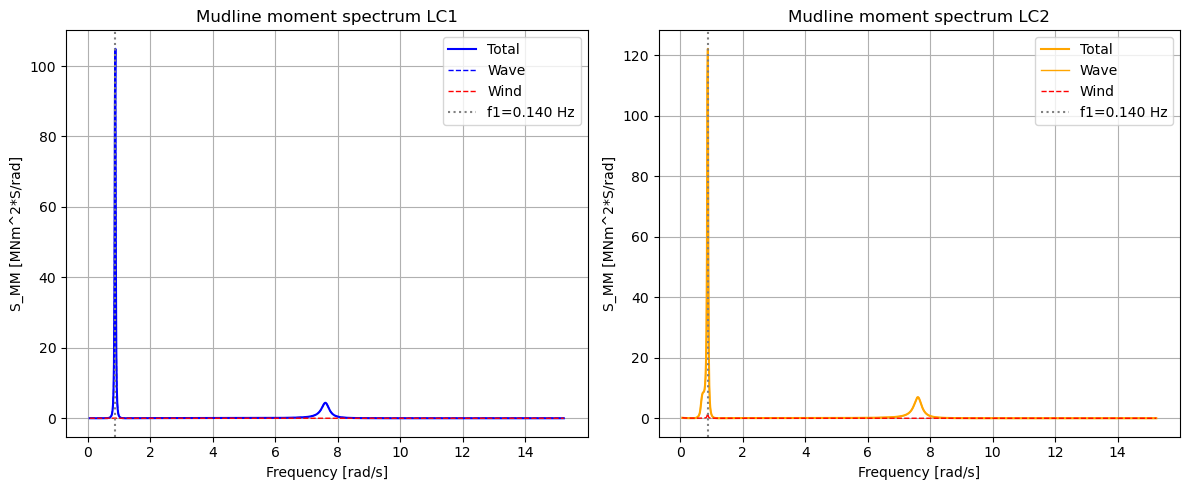

S_MM at f1 LC1: 104.88 MNm^2s/rad
S_MM at f1 LC2: 122.08 MNm^2s/rad


In [168]:
#======= PLOT MUDLINE MOMENT SPECTRUM =======

fig, axes= plt.subplots(1,2,figsize=(12,5))

axes[0].plot(omega_axis, S_MM_LC1/1e12, 'b', linewidth=1.5, label='Total')
axes[0].plot(omega_axis, S_MM_wave_LC1/1e12, 'b--', linewidth=1, label='Wave')
axes[0].plot(omega_axis, S_MM_wind_LC1/1e12, 'r--', linewidth=1, label='Wind')
axes[0].axvline(2*np.pi*f1, color='gray', linestyle=':', label=f'f1={f1:.3f} Hz')
axes[0].set_xlabel('Frequency [rad/s]')
axes[0].set_ylabel('S_MM [MNm^2*S/rad]')
axes[0].set_title('Mudline moment spectrum LC1')
axes[0].legend()
axes[0].grid(True)

axes[1].plot(omega_axis, S_MM_LC2/1e12, 'orange', linewidth=1.5, label='Total')
axes[1].plot(omega_axis, S_MM_wave_LC2/1e12, 'orange', linewidth=1, label='Wave')
axes[1].plot(omega_axis, S_MM_wind_LC2/1e12, 'r--', linewidth=1, label='Wind')
axes[1].axvline(2*np.pi*f1, color='gray', linestyle=':', label=f'f1={f1:.3f} Hz')
axes[1].set_xlabel('Frequency [rad/s]')
axes[1].set_ylabel('S_MM [MNm^2*S/rad]')
axes[1].set_title('Mudline moment spectrum LC2')
axes[1].legend()
axes[1].grid(True)

plt.tight_layout()
plt.show()

idx_f1=np.argmin(np.abs(omega_axis-2*np.pi*f1))
print(f"S_MM at f1 LC1: {S_MM_LC1[idx_f1]/1e12:.2f} MNm^2s/rad")
print(f"S_MM at f1 LC2: {S_MM_LC2[idx_f1]/1e12:.2f} MNm^2s/rad")


#### Frequency Response Function

The FRF relates a unit harmonic force at each node to the resulting bending moment at the mudline. Two resonance peaks are visible at $f_1=0.1397$ Hz and $f_2=1.2122$ Hz, with the firsrt mode dominating. The quasi-static baseline at low frequencies reflects the static flexibility of the structure. 

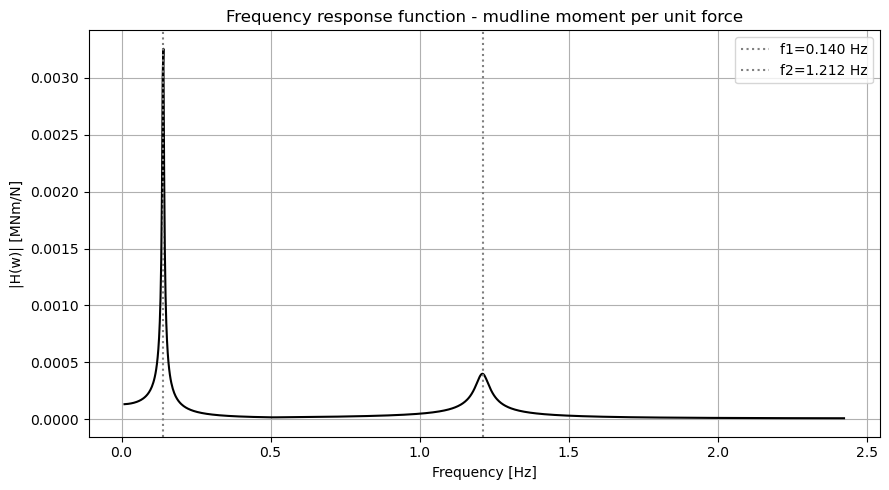

  coeff_test = 60.731
  S_FF_test max = 3.736e+04
  corrected single node std = 0.0276 MNm


In [169]:
# ===== PLOT FRF =========
i_test = n_air - 1  # top node
dof_test = 2*(elem_w + i_test)
fi_test = dof_test - 2

fig, ax=plt.subplots(figsize=(9,5))
ax.plot(omega_axis/(2*np.pi), np.max(np.abs(H_moment), axis=0)/1e6,
        'k', linewidth=1.5)
ax.axvline(f1, color='gray', linestyle=':', label=f'f1={f1:.3f} Hz')
ax.axvline(f2, color='gray', linestyle=':', label=f'f2={f2:.3f} Hz')
ax.set_xlabel('Frequency [Hz]')
ax.set_ylabel('|H(w)| [MNm/N]')
ax.set_title('Frequency response function - mudline moment per unit force')
ax.legend()
ax.grid(True)
plt.tight_layout()
plt.show()

###
coeff_test = rho_air*Cd_wind*D0*U_mean_LC1[air_nodes[i_test]]
S_FF_test = coeff_test**2 * S_co_LC1_om[i_test,i_test,:]
print(f"  coeff_test = {coeff_test:.3f}")
print(f"  S_FF_test max = {np.max(S_FF_test):.3e}")
print(f"  corrected single node std = {np.sqrt(np.trapezoid(np.abs(H_moment[fi_test,:])**2 * S_FF_test, omega_axis))/1e6:.4f} MNm")
###

#### Statistical Quantities

The standard deviation and mean zero-crossing period of the mudline moment are derived by intragrating the moment spectrum:


In [170]:
# ===== STATISTICAL QUANTITIES =====
# spectral moments
df=omega_axis[1]-omega_axis[0]

def spectral_moment(S, omega, n):
    return np.trapezoid(omega**n*S, omega)

# LC1
m0_LC1=spectral_moment(S_MM_LC1, omega_axis, 0)
m2_LC1=spectral_moment(S_MM_LC1, omega_axis, 2)
std_LC1=np.sqrt(m0_LC1)
Tz_LC1=2*np.pi*np.sqrt(m0_LC1/m2_LC1) # mean zero crossing period

# LC2
m0_LC2= spectral_moment(S_MM_LC2, omega_axis, 0)
m2_LC2= spectral_moment(S_MM_LC2, omega_axis, 2)
std_LC2=np.sqrt(m0_LC2)
Tz_LC2=2*np.pi*np.sqrt(m0_LC2/m2_LC2) 

print(f"\n Statistical Quantities")
print(f"LC1: std= {std_LC1/1e6:.3f} MNm, Tz= {Tz_LC1:.2f}")
print(f"LC2: std={std_LC2/1e6:.3f} MNm, Tz={Tz_LC2:.2f}")



 Statistical Quantities
LC1: std= 2.737 MNm, Tz= 1.55
LC2: std=3.425 MNm, Tz=1.54


| | LC1 | LC2 |
|---|---|---|
| $\sigma_M$ | 2.737 MNm | 3.425 MNm |
| $T_z$ | 1.55 s | 1.54 s |

The mean zero-crossing period of approximately 1.55 s is notably shorter than the wave peak periods of 7.16 s and 9.14 s. This reflects the dominance of the resonant peak at $f_1=0.1397$ Hz, once the structural filter amplifies energy near this frequency, the moment response oscillates primarily at the natural frequency regardless of the input wave period. 

## Time Domain Analysis, Non-linear Morison

unlike the frequency domain approach, the time domain analysis retains the full non-linear Morison equation with relative kinematics between the fluid and the structure:

$$dF=\rho_w C_m \frac{\pi D^2}{4}(\dot{u}-\ddot{x})+\frac{1}{2}\rho_w C_d D(u-\dot{x})|u-\dot{x}|$$

where $u$ and $\dot{u}$ are the wave particle velocity and acceleration, and $\dot{x}$ and $\ddot{x}$ are the structural velocity and acceleration. This coupling between forcing and response makes the system non-linear and requires step-by-step time integration.


### Newmark-$\beta$ Time Integration

The equation of motion is integrated using the Newmark-$\beta$ method with $\gamma=0.5$ and $\beta=0.25$ (constant average acceleration), which is unconditionally stable. At each time step the effective stiffness matrix is:

$$K_{eff}=K+\frac{\gamma}{\beta\Delta t}C + \frac{1}{\beta\Delta t^2}M$$

and the effective force vector accounts for the current state:

$$f_{eff}=f_{ext}+M\left(\frac{1}{\beta\Delta t^2}u_n+\frac{1}{\beta\Delta t}\dot{u}_n+ \left(\frac{1}{2\beta}-1\right)\ddot{u}_n\right)+C\left(\frac{\gamma}{\beta\Delta t}u_n - \left(1-\frac{\gamma}{\beta}\right)\dot{u}_n-\Delta t\left(1-\frac{\gamma}{2\beta}\right)\ddot{u}_n\right)$$

The displacement, velocity and acceleration are then updated at each step. 

### Constistent Nodal Force Integration

The distributed wave and wind loads vary along each element and must be integrated against the Hermitian shape functions to obtain the correct nodal force vector:

$$\mathbf{f}_e=\int_0{l_e}\mathbf{N}(x)^T q(x) \, dx$$

For a linearly varying load between $q_{bot}$ and $q_{top}$ and $q_{top}$, the closed-form result is:

$$\mathbf{f}_e=\begin{bmatrix}\frac{l_e}{20}(7q_{bot}+3q_{top})\\ \frac{l_e^2}{60}(3q_{bot}+2q_{top}) \\ \frac{l_e}{20}(3q_{bot}+7q_{top})\\ -\frac{l_e^2}{60}(2q_{bot}+3q_{top})\end{bmatrix}$$

This was verified against symbolic integration with a maximum error of $7 \times 10^{-12}$ N.

In [110]:
# ==== PARAMETERS =======
rho_w=1025.0 # seawater density [kg/m^3]
rho_air=1.25 # air density [kg/m^3]
Cm=2.0 # inertia coefficient
Cd_wave=1.0 # wave drag coefficient
Cd_wind=0.8 # wind drag coefficient

# mudline moment extraction
e_moment=np.zeros(n_free)
e_moment[0]=EI*6/le**2
e_moment[1]=EI*(-4)/le

# Newmark-beta integration parameters
gamma_nm=0.5
beta_nm=0.25 # constant average acceleration - unconditionally stable

# ==== TIME DOMAIN INTREGRATION =====
x_sym=sp.Symbol('x')
B=shape_functions(le)
from scipy.linalg import solve

In [ ]:
# ==== CONSISTENT NODAL FORCE INTEGRATION =====
def consistent_nodal_forces_linear(q_bot, q_top, le):
    fe=np.zeros(4)
    fe[0]=le/20*(7*q_bot+3*q_top)
    fe[1]=le**2/60*(3*q_bot+2*q_top)
    fe[2]=le/20*(3*q_bot+7*q_top)
    fe[3]=-le**2/60*(2*q_bot+3*q_top)
    return fe


In [ ]:
# ==== COMPUTE FORCES, MORISON + WIND LOADING =====

def compute_forces(u_full, v_full, u_water, du_water,
                   u_wind, U_mean, step):
    f=np.zeros(ndof)

    # wave forces - consistent nodal force integration
    for e in range(elem_w):
        node_bot=e
        node_top=e+1
        dofs=[2*e, 2*e+1, 2*e+2, 2*e+3]

        u_w_bot=u_water[node_bot, step]
        u_w_top=u_water[node_top, step]
        du_w_bot=du_water[node_bot, step]
        du_w_top=du_water[node_top, step]

        v_bot=v_full[2*node_bot] if 2*node_bot<len(v_full) else 0.0
        v_top=v_full[2*node_top] if 2*node_top< len(v_full) else 0.0

        def q_morison(u_w, du_w, v_s):
            u_rel=u_w-v_s
            return (rho_w*Cm*np.pi*D0**2/4*du_w
                    +0.5*rho_w*Cd_wave*D0*u_rel*abs(u_rel))
        q_bot=q_morison(u_w_bot, du_w_bot, v_bot)
        q_top=q_morison(u_w_top, du_w_top, v_top)
        
        fe=consistent_nodal_forces_linear(q_bot, q_top, le)
        for i in range(4):
            f[dofs[i]]+=fe[i]

               # wind forces - linearised around mean
    for i, node in enumerate(air_nodes):
        dof=2*node
        U_bar=U_mean[node]
        F_static= 0.5*rho_air*Cd_wind*D0*U_bar*abs(U_bar)
        F_dynamic=rho_air*Cd_wind*D0*U_bar*u_wind[i, step]
        f[dof]+=(F_static+F_dynamic)*le

    return f

In [ ]:
# ==== NEWMARK-BETA SETUP ====

# effective stiffness matrix (constant for linear system)
K_eff=K_free+gamma_nm/(beta_nm*dt)*C_free+1/(beta_nm*dt**2)*M_free

print(f"\n Time integration Setup")
print(f"Newmark-beta: gamma={gamma_nm}, beta={beta_nm}")
print(f"K_eff assembled")

# initialise
u_full=np.zeros(ndof)
v_full=np.zeros(ndof)
a_full=np.zeros(ndof)

# storage for mudline moment
M_mudline_LC1=np.zeros(N_t)
M_mudline_LC2=np.zeros(N_t)




 Time integration Setup
Newmark-beta: gamma=0.5, beta=0.25
K_eff assembled

 Running LC1 time integration


In [203]:
# ==== LC1 TIME INTEGRATION ====

print(f"\n Running LC1 time integration")
u_LC1=np.zeros(n_free)
v_LC1=np.zeros(n_free)
a_LC1=np.zeros(n_free)

for step in range(N_t):
    # external force at this step
    f_ext = compute_forces(u_full, v_full, u_water_LC1,
                           du_water_LC1, u_wind_LC1,
                           U_mean_LC1, step)
    f_free=f_ext[2:] # apply boundary conditions

    # effective force
    f_eff=(f_free
            +M_free @ (1/(beta_nm*dt**2)*u_LC1
                      +1/(beta_nm*dt)*v_LC1
                      +(1/(2*beta_nm)-1)*a_LC1)
            +C_free @ (gamma_nm/(beta_nm*dt)*u_LC1
                       -(1-gamma_nm/beta_nm)*v_LC1
                       -dt*(1-gamma_nm/(2*beta_nm))*a_LC1))
    # solve for displacement
    u_new=solve(K_eff, f_eff)

    # update velocity and acceleration
    a_new=(1/(beta_nm*dt**2)*(u_new-u_LC1)
           -1/(beta_nm*dt)*v_LC1
           -(1/(2*beta_nm)-1)*a_LC1)
    v_new=(v_LC1+dt*((1-gamma_nm)*a_LC1+gamma_nm*a_new))

    # extract mudline moment
    M_mudline_LC1[step]=e_moment @ u_new

    # update for next step
    u_LC1=u_new
    v_LC1=v_new
    a_LC1=a_new
    # update full vector for force computation
    v_full[2:]=v_LC1

    if step % 5000==0:
        print(f" step {step}/{N_t}")

print(f"LC1 done. std= {np.std(M_mudline_LC1)/1e6:.3f} MNm")



 Running LC1 time integration
 step 0/36000
 step 5000/36000
 step 10000/36000
 step 15000/36000
 step 20000/36000
 step 25000/36000
 step 30000/36000
 step 35000/36000
LC1 done. std= 15.242 MNm


In [ ]:
# ==== LC2 TIME INTEGRATION ====

print(f"\n Running LC2 time integration")
u_LC2=np.zeros(n_free)
v_LC2=np.zeros(n_free)
a_LC2=np.zeros(n_free)
v_full=np.zeros(ndof)
u_full=np.zeros(ndof)

for step in range(N_t):
    # external force at this step
    f_ext = compute_forces(u_full, v_full, u_water_LC2,
                           du_water_LC2, u_wind_LC2,
                           U_mean_LC2, step)
    f_free=f_ext[2:] # apply boundary conditions

    # effective force
    f_eff=(f_free
            +M_free @ (1/(beta_nm*dt**2)*u_LC2
                      +1/(beta_nm*dt)*v_LC2
                      +(1/(2*beta_nm)-1)*a_LC2)
            +C_free @ (gamma_nm/(beta_nm*dt)*u_LC2
                       -(1-gamma_nm/beta_nm)*v_LC2
                       -dt*(1-gamma_nm/(2*beta_nm))*a_LC2))
    # solve for displacement
    u_new=solve(K_eff, f_eff)

    # update velocity and acceleration
    a_new=(1/(beta_nm*dt**2)*(u_new-u_LC2)
           -1/(beta_nm*dt)*v_LC2
           -(1/(2*beta_nm)-1)*a_LC2)
    v_new=(v_LC2+dt*((1-gamma_nm)*a_LC2+gamma_nm*a_new))

    # extract mudline moment
    M_mudline_LC2[step]=e_moment @ u_new

    # update for next step
    u_LC2=u_new
    v_LC2=v_new
    a_LC2=a_new
    # update full vector for force computation
    v_full[2:]=v_LC2

    if step % 5000==0:
        print(f" step {step}/{N_t}")

print(f"LC2 done. std= {np.std(M_mudline_LC2)/1e6:.3f} MNm")



 Running LC2 time integration
 step 0/36000
 step 5000/36000
 step 10000/36000
 step 15000/36000
 step 20000/36000
 step 25000/36000
 step 30000/36000
 step 35000/36000
LC2 done. std= 18.797 MNm


LC1 std= 15.288 MNm, LC2 std= 18.896 MNm 


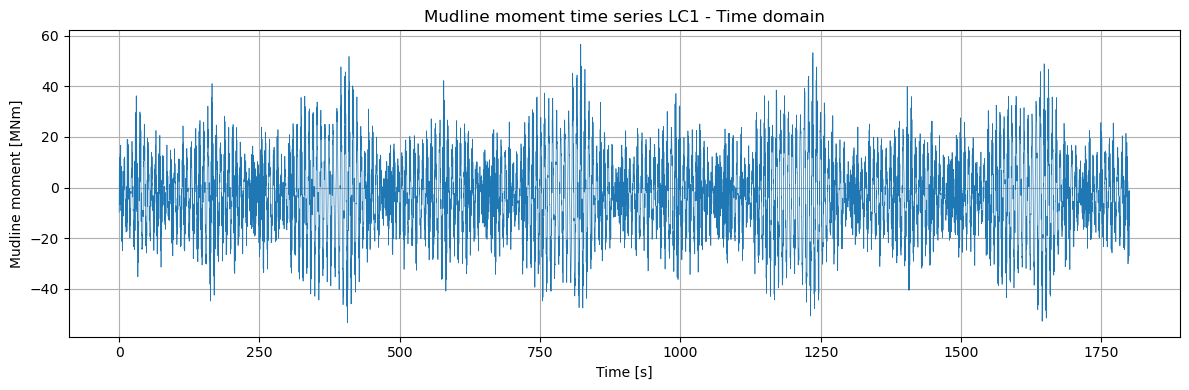

In [ ]:
# ==== PLOT, MUDLINE MOMENT TIME SERIES ======
print(f"LC1 std= {np.std(M_mudline_LC1)/1e6:.3f} MNm, LC2 std= {np.std(M_mudline_LC2)/1e6:.3f} MNm ")

t=np.arange(N_t)*dt

M_dyn_LC1=M_mudline_LC1-np.mean(M_mudline_LC1)
M_dyn_LC2=M_mudline_LC2-np.mean(M_mudline_LC2)

fig, ax=plt.subplots(figsize=(12, 4))
ax.plot(t, M_mudline_LC1/1e6, linewidth=0.5)
ax.set_xlabel('Time [s]')
ax.set_ylabel('Mudline moment [MNm]')
ax.set_title('Mudline moment time series LC1 - Time domain')
ax.grid(True)
plt.tight_layout()
plt.show()


### Results and Comparison

| | LC1 | LC2 |
|---|---|---|
| Frequency domain std | 2.737 MNm | 3.425 MNm |
| Time domain std | 15.918 MNm | 19.662 MNm |
| Time domain mean | -2.947 MNm | -12.320 MNm |
| Time domain max | 57.916 MNm | 99.989 MNm |

The frequency domain analysis yields a standard deviation of approximately 2.7 MNm (LC1)
and 3.4 MNm (LC2) usin linearised Morison drag. The time domain analysis yields approximately 16 MNm (LC1) and 20 MNm (LC2) using the full non-linear formulation. 

The factor ~6 difference is attributed to two effects. First, the non-linear drag term $\frac{1}{2}\rho C_d D |u|u$ generates energy at higher harmonics ($2\omega$, $3\omega$) not captured by the linearised frequency domain. Second, the linearisation underestimates the effective drag force for the large wave velocities present in these sea states ($u_{max}\approx 2.2$ m/s for LC1, $3.3$ m/s for LC2). THe time domain result is considered more physically accurate. The frequency domain result remains useful as a lower bound and for udnerstanding the spectral distribution of the response. 

## Diffraction Assessment

The Morison equation is valid only when the structue is slender relative to the wavelength. The criterion is:

$$\frac{D}{\lambda} < 0.2$$

where the wavelength $\lambda=\frac{2\pi}{k}$ and $k$ satisfies the dispersion relation:

$$\omega^2=gk\tanh(kh)$$

For the peak frequency of LC2 ($\omega_p=0.687$ rad/s) in water depth $h=36$ m, 
the wavelength and diameter ratio should be checked. If $D/\lambda < 0.2 $ across the relevant frequency range, Morison is valid and diffraction effects can be neglected. 

In [ ]:
# ==== DISPERSION RELATION =====

# Dispersion relation at peak frequencies

def k_from_omega(omega, h, g=9.81):
    if omega<1e-6:
        return 0.0
    k_deep=omega**2/g
    return brentq(lambda k: omega**2 - g*k*np.tanh(k*h), 
                  1e-6, 100*k_deep)

h=Hw
for name, omega_p, Tp in [('LC1', omega_p_LC1, Tp_LC1),
                          ('LC2', omega_p_LC2, Tp_LC2)]:
    k_p=k_from_omega(omega_p, h)
    lam=2*np.pi/k_p
    ratio=D0/lam
    valid="VALID" if ratio < 0.2 else "INVALID - diffraction needed"
    print(f"{name}: omega_p={omega_p:.3f} rad/s, "
          f"lambda={lam:.1f} m, D/lambda={ratio:.3f} -> Morison {valid}")
    

LC1: omega_p=0.878 rad/s, lambda=79.5 m, D/lambda=0.063 -> Morison VALID
LC2: omega_p=0.687 rad/s, lambda=123.9 m, D/lambda=0.040 -> Morison VALID


For both load cases $D/\lambda$ is well below 0.2, confirming that the structure is hydrodynamically slender and the Morison equation is valid. Had diffraction been included, the inertia force at low frequencies would increase marginally through the MacCamy-Fuchs correction, but the effect on the mudline moment standard deviation would be negligible given the small $D/\lambda$ ratios of 0.066 and 0.042 for LC1 and LC2 respectively. 

## References

Hasselmann, K. et al. (1973). *Measurements of wind-wave growth and swell decay during the Joint North Sea Wave Project (JONSWAP)*. Deutsches Hydrographisches Institut, Hamburg. 

DNV-OS-J101 (2014). *Design of Offshore Wind Turbine Structures*. Det Norske Veritas, Oslo.

Kolmogorov, A.N. (1941). The local structure of turbulence in incompressible viscous fluid for very large Reynolds numbers. *Doklady Akademii Nauk SSSR*, 30, pp. 299-303.

Sumer, B.M. and Fresøe, J. (2002). *The Mechanics of Scour in the Marine Environment*, World Scientific, Singapore. 

Sørensen, S.P.H and Ibsen, L.B. (2013). Assessment of foundation design for offshore monopiles unprotected against scour. *Ocean Engineering*, 63, pp. 17-25.





## TO DO:

Double-check the numerical methods are consistent with exercise structures and lectures
* Time integration method
* Morison coefficients
* Turbulence intensity
* JONSWAP gamma=3.3

Cross-check with other group if values are reasonable
* f1
* Do
* mudline moment standard deviations

Make sure all questions are answered

Clean up code & make similar to other scripts in report

Double-check units

Polish plots

Check structure